In [1]:
# 구글 드라이브 마운트하기
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 작업 디렉토리 설정하기
import os

wd = "/content/drive/MyDrive/codit_data"
os.chdir(wd)
os.getcwd()

'/content/drive/MyDrive/codit_data'

In [3]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
# koreanize-matplotlib 라이브러리 설치(한글)
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 32.9 MB/s eta 0:00:00


In [7]:
# koreanize-matplotlib 라이브러리 불러오기
import koreanize_matplotlib

# 기술 통계

**통계**

- 어떤 현상을 종합적으로 한눈에 알아보기 쉽게 일정한 체계에 따라 숫자로 나타내는 것

**통계의 두 가지 분야: 기술 통계 vs 추론 통계**

- 기술 통계(descriptive statistics): 숫자를 이용하여 자료의 정보를 요약 기술하는 것
- 추론 통계(inferential statistics): 실험이나 관찰을 통하여 얻은 자료를 분석하여 표본을 바탕으로 모집단에 정보를 유추하는 것

**기술 통계량(Descriptive Statistics)** : 데이터를 요약·설명하는 값들

- (1) 평균(mean): 데이터 합계 ÷ 데이터 개수

- (2) 중앙값(median): 데이터를 정렬했을 때 중앙에 위치한 값(짝수 개면 가운데 두 값의 평균)

- (3) 사분위수(quartiles): 데이터를 4등분한 값. Q1(25%)/Q2(50%, 중앙값)/Q3(75%)/Q4(100%, 최댓값)

- (4) 최빈값(mode): 가장 자주 등장하는 값

**데이터 유형**
- 수치형 데이터(numerical data) : 사칙연산 가능, 크기 비교 가능
- 범주형 데이터(categorical data) : 최빈값/종류 수 파악 가능

In [8]:
exam_df = pd.read_csv("exam.csv")
exam_df

,math_score,science_score,english_score,second_lang
0,45.0,68.0,68.0,Chinese
1,80.0,44.0,78.0,Japanese
2,37.5,50.0,78.0,Chinese
3,57.5,56.0,78.0,Russian
4,45.0,68.0,82.0,Chinese
...,...,...,...,...
195,45.0,50.0,72.0,German
196,52.5,44.0,82.0,German
197,57.5,54.0,84.0,Chinese
198,50.0,54.0,74.0,French


- `describe`: 컬럼별로 기본적인 통계 정보 확인 가능하고, `describe`은 수치형 데이터에 대해서 계산

In [ ]:
exam_df.describe()

,math_score,science_score,english_score
count,200.000000,200.00000,200.000000
mean,52.830000,54.98750,77.547500
std,12.961912,9.42178,9.165507
min,15.000000,20.00000,25.000000
25%,45.000000,48.00000,72.000000
50%,52.500000,56.00000,78.000000
75%,60.000000,62.00000,84.000000
max,95.000000,90.00000,94.000000


- `describe`: 컬럼별로 기본적인 통계 정보 확인 가능하고, `describe`은 수치형 데이터에 대해서 계산
  - `include='all'`: 수치형 데이터 포함 모든 데이터 유형에 대해서 보고 싶을 때
  - `top`(최빈값), `freq`(최빈값 등장 횟수)


In [ ]:
exam_df.describe(include='all')

,math_score,science_score,english_score,second_lang
count,200.000000,200.00000,200.000000,200
unique,NaN,NaN,NaN,5
top,NaN,NaN,NaN,Chinese
freq,NaN,NaN,NaN,65
mean,52.830000,54.98750,77.547500,NaN
std,12.961912,9.42178,9.165507,NaN
min,15.000000,20.00000,25.000000,NaN
25%,45.000000,48.00000,72.000000,NaN
50%,52.500000,56.00000,78.000000,NaN
75%,60.000000,62.00000,84.000000,NaN


## (1) 대표값 : 평균 vs 중앙값

**평균 vs 중앙값**

- 평균과 중앙값은 모두 대표값이지만, 이상치가 있을 때는 중앙값이 더 안정적인 지표

**이상치(outlier)**

- 데이터 집합에서 다른 값들과 비교해 현저히 크거나 작은 값
- 이상치 발생 원인

  (1) 오류 : 잘못 입력된 값
  
  (2) 극단값 : 실제로 매우 특이한 값

In [ ]:
# 평균(mean), 중앙값(50%)
exam_df.describe(include='all')

,math_score,science_score,english_score,second_lang
count,200.000000,200.00000,200.000000,200
unique,NaN,NaN,NaN,5
top,NaN,NaN,NaN,Chinese
freq,NaN,NaN,NaN,65
mean,52.830000,54.98750,77.547500,NaN
std,12.961912,9.42178,9.165507,NaN
min,15.000000,20.00000,25.000000,NaN
25%,45.000000,48.00000,72.000000,NaN
50%,52.500000,56.00000,78.000000,NaN
75%,60.000000,62.00000,84.000000,NaN


In [9]:
# 예시 데이터
data = {"math_score": [52, 60, 70, 52, 90, 60, 52, 60]}
df = pd.DataFrame(data)
df

,math_score
0,52
1,60
2,70
3,52
4,90
5,60
6,52
7,60


In [10]:
df['math_score'].mode() #    최빈갑ㅅ

,math_score
0,52
1,60


## (2) 산포도 : 분산과 표준편차

**분산과 표준편차**

- 목적: 데이터 값들이 얼마나 퍼져 있는지를 수치로 표현

(1) 분산(variance): 편차를 제곱한 값들의 평균으로 제곱을 하는 이유는 편차를 양수화함과 동시에 큰 편차를 더 강조하기 위함이다.
  - 편차(deviation): 각 데이터 값과 평균의 차이로 편차의 합은 항상 0이다.

(2) 표준편차(standard deviation): 분산에 제곱근(루트)을 씌운 값으로 루트를 씌우는 이유는 제곱된 단위를 원래 데이터 단위로 되돌리기 위함이다.

**해석**

- 분산/표준편차 작다 → 값들이 평균 근처에 몰려 있다
- 분산/표준편차 크다 → 값들이 평균에서 멀리 퍼져 있다

In [22]:
# 데이터 불러오기
body_df = pd.read_csv('body.csv')
body_df.head()

,height,weight
0,188.3,85.8
1,176.2,78.0
2,175.9,75.6
3,181.1,85.1
4,182.6,82.3


In [23]:
body_df.shape

(500, 2)

In [24]:
# 표준편차(std)
body_df.describe()

,height,weight
count,500.00000,500.000000
mean,173.26280,75.542600
std,7.27484,7.303482
min,151.30000,54.100000
25%,168.50000,70.775000
50%,172.95000,75.300000
75%,178.22500,80.650000
max,195.80000,95.600000


In [25]:
# 분산
body_df['height'].var()

52.92330276553104

In [26]:
# 표준편차
body_df['height'].std()

7.274840394505644

## (3)누적값 계산하기

- `cumsum()`: 누적 합계
- `cumprod()`: 누적 곱

(예시)

In [27]:
revenue_df = pd.read_csv("revenue.csv")
revenue_df

,month,revenue
0,1,35.8
1,2,29.7
2,3,36.3
3,4,39.6
4,5,45.5
5,6,49.4
6,7,105.1
7,8,123.5
8,9,155.4
9,10,221.8


In [28]:
revenue_df['revenue_cumsum'] = revenue_df['revenue'].cumsum()

In [29]:
revenue_df

,month,revenue,revenue_cumsum
0,1,35.8,35.8
1,2,29.7,65.5
2,3,36.3,101.8
3,4,39.6,141.4
4,5,45.5,186.9
5,6,49.4,236.3
6,7,105.1,341.4
7,8,123.5,464.9
8,9,155.4,620.3
9,10,221.8,842.1


<Axes: xlabel='month'>

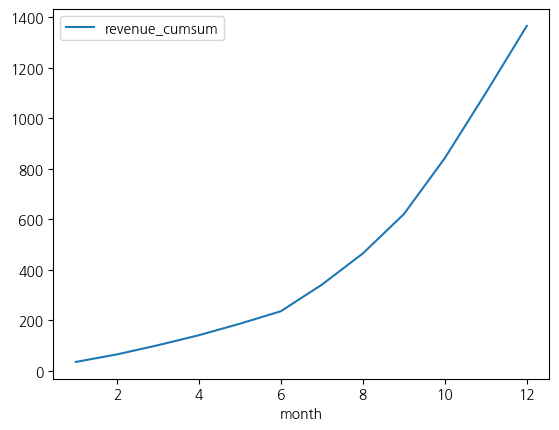

In [30]:
# 선 그래프
revenue_df.plot(x='month', y='revenue_cumsum')

<Axes: >

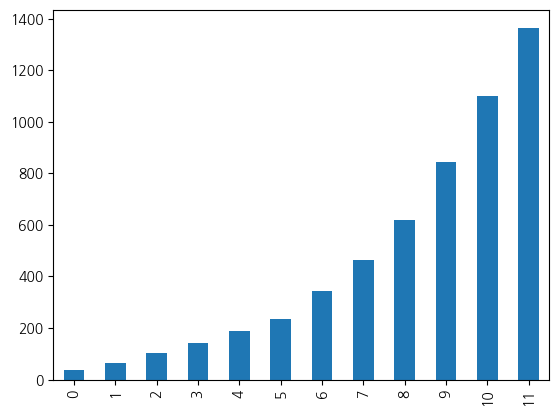

In [31]:
# 막대 그래프
revenue_df['revenue_cumsum'].plot(kind='bar')

(예시)

In [32]:
interest_df = pd.read_csv("interest.csv")
interest_df

,year,interest
0,2001,0.0546
1,2002,0.0471
2,2003,0.0415
3,2004,0.0375
4,2005,0.0357
5,2006,0.0436
6,2007,0.0501
7,2008,0.0567
8,2009,0.0323
9,2010,0.0318


In [33]:
interest_df['multiple'] = 1 + interest_df['interest']

In [34]:
interest_df['cumulative_multiple'] = interest_df['multiple'].cumprod()
interest_df

,year,interest,multiple,cumulative_multiple
0,2001,0.0546,1.0546,1.054600
1,2002,0.0471,1.0471,1.104272
2,2003,0.0415,1.0415,1.150099
3,2004,0.0375,1.0375,1.193228
4,2005,0.0357,1.0357,1.235826
5,2006,0.0436,1.0436,1.289708
6,2007,0.0501,1.0501,1.354322
7,2008,0.0567,1.0567,1.431112
8,2009,0.0323,1.0323,1.477337
9,2010,0.0318,1.0318,1.524317


# 데이터 시각화 기초

# [1] matplotlib

- 파이썬에서 데이터를 시각화하는 대표적인 라이브러리로, 세부 설정이 자유로워 맞춤형 시각화 가능
  - `matplotlib`: 데이터를 시각적으로 표현하는 그래프(차트) 라이브러리
  - `pyplot` 모듈: `plt.plot()`, `plt.bar()`처럼 간단한 명령형을 통해 다양한 그래프를 쉽게 만들 수 있도록 도와주는 도구

## (1) Line Plot

**선 그래프(Line Plot)**  
- 시간에 따른 변화 추이를 보여줄 때 사용하고, 데이터 포인트 간의 연속성을 강조  
- 예: 월별 매출 변화, 온도 변화 추세

In [35]:
year_array = np.array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020])

stock_array = np.array([
    14.46, 19.01, 20.04, 27.59, 26.32,
    28.96, 42.31, 39.44, 73.41, 132.69
])

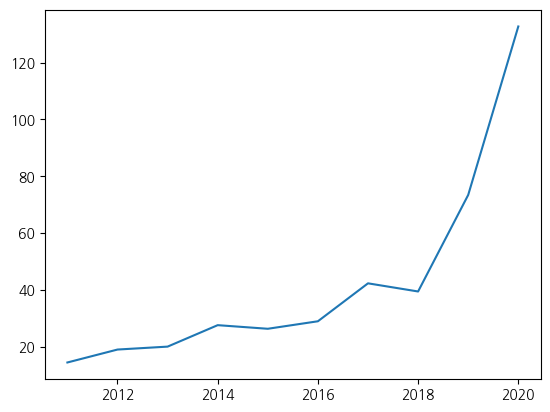

In [36]:
plt.plot(year_array, stock_array)
plt.show()

##  (2) Bar Plot

**막대 그래프(Bar Plot)**  
- 범주(카테고리)별 비교를 할 때 사용하고, 데이터 값의 크기 차이를 직관적으로 표현  
- 예: 부서별 인원 수, 제품별 판매량

In [37]:
name_array = np.array(['A', 'B', 'C', 'D', 'E'])
votes_array = np.array([5, 10, 6, 8, 3])

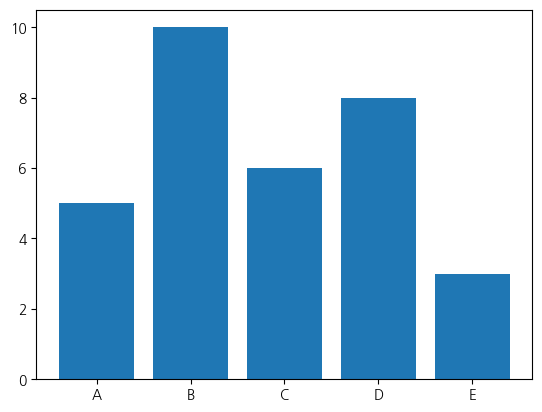

In [38]:
plt.bar(name_array, votes_array)
plt.show()

## (3) Scatter Plot

**산점도(Scatter Plot)**

- 두 변수 간의 관계를 점(좌표)으로 표현한 그래프로 변수 간의 상관관계를 파악하거나 데이터의 분포와 패턴 확인
- 예시: 키와 몸무게 관계, 광고비와 매출액 관계

In [ ]:
height_array = np.array([
    165, 164, 155, 151, 157, 162, 155, 157, 165, 162,
    165, 167, 167, 183, 180, 184, 177, 178, 175, 181,
    172, 173, 169, 172, 177, 178, 185, 186, 190, 187
])

weight_array = np.array([
    62, 59, 57, 55, 60, 58, 51, 56, 68, 64,
    57, 58, 64, 79, 73, 76, 61, 65, 83, 80,
    67, 82, 88, 62, 61, 79, 81, 68, 83, 80
])

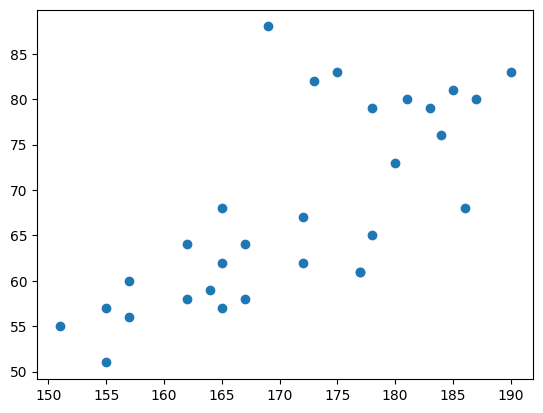

In [ ]:
plt.scatter(height_array, weight_array)
plt.show()

(그래프 간단하게 꾸미기)

[마커 종류](https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers)

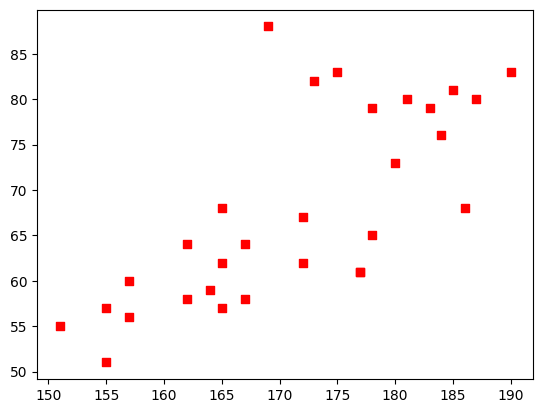

In [ ]:
plt.scatter(height_array, weight_array, c='red', marker='s')
plt.show()

## (4) Box Plot

**상자 그림(Box Plot)**

- 데이터 분포와 이상치를 시각적으로 보여주는 그래프로 여러 그룹 간 분포 비교에 유용하고 IQR을 이용해 이상치를 판별한다.

**상자 그림 해석**
- 가로선(Line) / 중앙선: 중앙값(Median, Q2)
- 수염(Whiskers): 상자 밖으로 뻗은 선으로, 정상 범위 내의 최솟값과 최댓값까지 표시
- 점(Dots): 정상 범위를 벗어난 이상치 표시

**이상치 판별 기준**

- IQR(사분위 범위) = Q3 - Q1(3사분위수에서 1사분위수를 뺀 값)으로 데이터의 중간 50% 범위를 의미
- 정상 범위를 계산했을 때, 상한과 하한을 벗어난 값들을 이상치라고 한다.
  - 하한 = Q1 - (1.5 × IQR)
  - 상한 = Q3 + (1.5 × IQR)

In [ ]:
df = pd.read_csv("exam.csv")
df.head()

,math_score,science_score,english_score,second_lang
0,45.0,68.0,68.0,Chinese
1,80.0,44.0,78.0,Japanese
2,37.5,50.0,78.0,Chinese
3,57.5,56.0,78.0,Russian
4,45.0,68.0,82.0,Chinese


In [ ]:
df['english_score'].describe()

,english_score
count,200.000000
mean,77.547500
std,9.165507
min,25.000000
25%,72.000000
50%,78.000000
75%,84.000000
max,94.000000


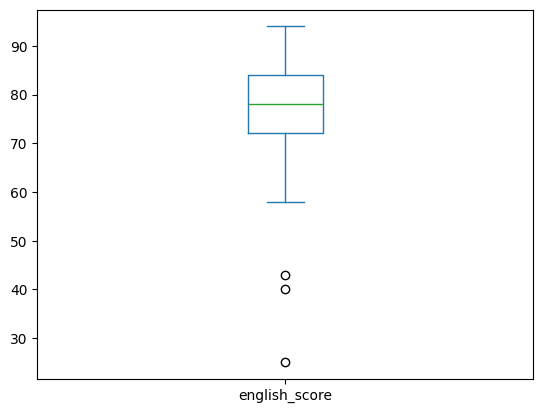

In [ ]:
# english_score 상자 그림 및 이상치 파악
df['english_score'].plot(kind='box')
plt.show()

In [ ]:
# IQR 기반 이상치 파악
q3 = df['english_score'].quantile(0.75)
q1 = df['english_score'].quantile(0.25)

iqr = q3 - q1

lower_limit = q1 - 1.5*iqr
upper_limit = q3 + 1.5*iqr

print(q1, q3, iqr, lower_limit, upper_limit)

72.0 84.0 12.0 54.0 102.0


In [ ]:
df[df['english_score'] < lower_limit]

,math_score,science_score,english_score,second_lang
124,40.0,20.0,43.0,Chinese
144,40.0,29.0,25.0,Japanese
145,18.5,23.0,40.0,Chinese


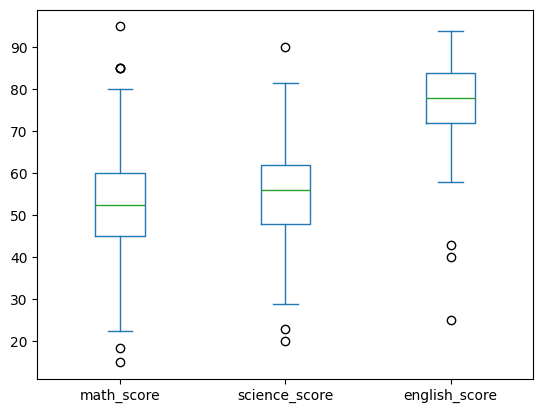

In [ ]:
# 모든 변수 상자 그림 및 이상치 파악
df.plot(kind='box')
plt.show()

## (5) Histogram

**히스토그램**

- 수치형 데이터를 구간별로 묶어 분포 형태와 패턴을 직관적으로 파악할 때 유용하고, 값을 일정한 구간(bin)으로 나누어, 각 구간에 속하는 데이터 개수를 막대 높이로 표시

**데이터 유형**

- 이산형(discrete): 개수, 사건 횟수 등
- 연속형(continuous): 키, 몸무게, 온도 등

**언제 사용?**

(1) 데이터의 전반적인 분포 파악 : 값들이 어떤 범위에 몰려 있는지, 퍼져 있는지 확인 가능

(2) 중심 경향과 변동성 확인 : 대략적인 평균, 퍼짐 정도, 치우침(왜도) 파악 가능

(3) 이상치 탐색 전 단계 : 특정 구간에 예상보다 적거나 많은 데이터가 있을 경우 이상치 가능성 확인

(4) 데이터 비교 : 두 개 이상의 집단이 비슷한 분포를 가지는지 비교할 때

(5) 정규성 판단 : 데이터가 종 모양(정규분포)에 가까운지 시각적으로 확인

In [39]:
df = pd.read_csv("body.csv")
df.head()

,height,weight
0,188.3,85.8
1,176.2,78.0
2,175.9,75.6
3,181.1,85.1
4,182.6,82.3


(참고)

- 히스토그램에서는 `bins`를 따로 설정을 하지 않으면, 구간을 10개로 나눈다.
- 히스토그램의 목적은 구간별로 데이터가 얼마나 많은지 보는 것이므로 상황에 맞게 적당한 구간 수를 정하는 것이 중요하다.

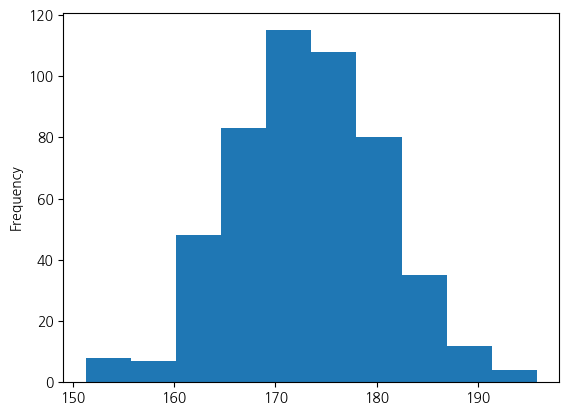

In [40]:
# 히스토그램 시각화
df['height'].plot(kind='hist')
plt.show()

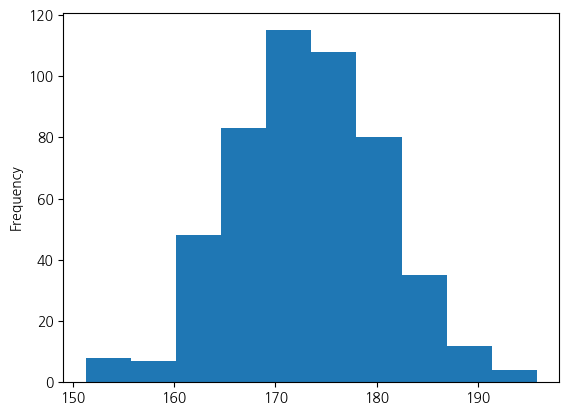

In [44]:
# 히스토그램 시각화
df['height'].plot(kind='hist', bins=10)
plt.show()

## (6) KDE Plot

**KDE Plot(Kernel Density Estimation)**

- 표본 데이터를 바탕으로 확률 밀도 함수를 추정하고, 연속형 데이터의 분포를 부드럽게 표현

In [ ]:
body = pd.read_csv("body.csv")
body.head()

,height,weight
0,188.3,85.8
1,176.2,78.0
2,175.9,75.6
3,181.1,85.1
4,182.6,82.3


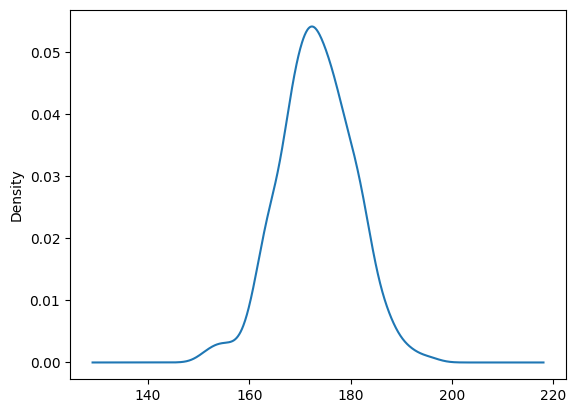

In [ ]:
# KDE Plot
body['height'].plot(kind='kde')
plt.show()

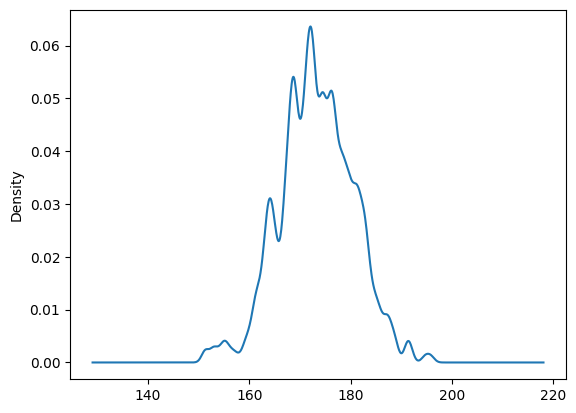

In [ ]:
# KDE Plot
body['height'].plot(kind='kde', bw_method=0.1)
plt.show()

# [2] seaborn

- **seaborn** : matplotlib 기반 통계 시각화 라이브러리

- **장점**  
  - 코드가 간결하고, 기본 스타일이 세련되어 빠르게 가독성 높은 그래프 생성

- **matplotlib과 비교**  
  - matplotlib : 원하는 대로 커스터마이징 가능  
  - seaborn : 기본 그래프가 깔끔하고 통계 시각화에 특화

| 변수명        | 설명 |
|---------------|------------------------------------------------|
| month         | 월|
| day           | 일|
| quarter       | 분기|
| day_of_week   | 요일 (0=월요일, 6=일요일) |
| workingday    | 근무일 여부 (1=평일이면서 휴일 아님, 0=주말/휴일) |
| holiday       | 공휴일 여부 (1=공휴일, 0=평일/주말) |
| temperature   | 기온 (섭씨) |
| humidity      | 습도 (0~100) |
| windspeed     | 풍속 (m/s) |
| registered    | 등록된 사용자(회원)의 이용 건수 |
| casual        | 비회원(일시 사용자)의 이용 건수 |
| total         | 전체 이용 건수 (`registered + casual`) |

## (1) Line Plot

In [45]:
bike_df = pd.read_csv("bike.csv")
bike_df.head()

,month,day,quarter,day_of_week,workingday,holiday,temperature,humidity,windspeed,registered,casual,total
0,1,1,1Q,SUN,0,0,21.4,72,12,1608,686,2294
1,1,2,1Q,MON,0,1,15.0,44,19,1707,244,1951
2,1,3,1Q,TUE,1,0,7.6,39,23,2147,89,2236
3,1,4,1Q,WED,1,0,0.4,35,11,2273,95,2368
4,1,5,1Q,THU,1,0,14.2,49,6,3132,140,3272


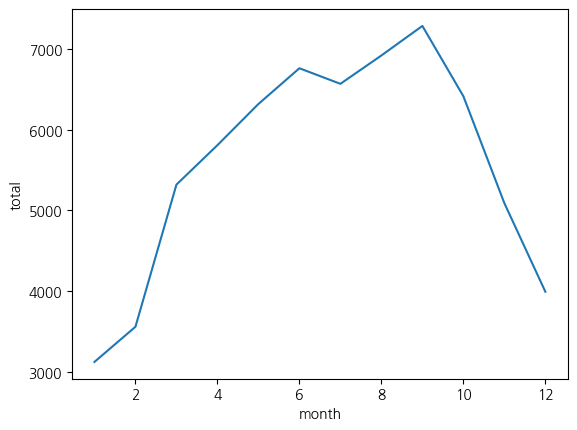

In [46]:
sns.lineplot(data=bike_df, x='month', y='total', errorbar=None)
plt.show()

- 일시 사용자(비회원)들의 근무일과 근무일이 아닌 날의 추이를 파악할 수 있다.

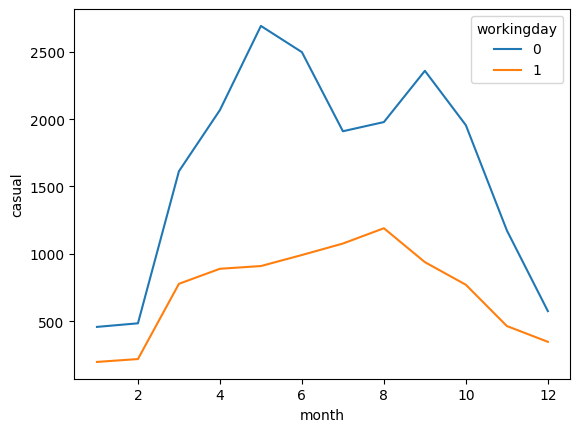

In [ ]:
sns.lineplot(data=bike_df, x='month', y='casual', errorbar=None, hue='workingday')
plt.show()

- 등록된 사용자(회원)들의 근무일과 근무일이 아닌 날의 추이를 파악할 수 있다.

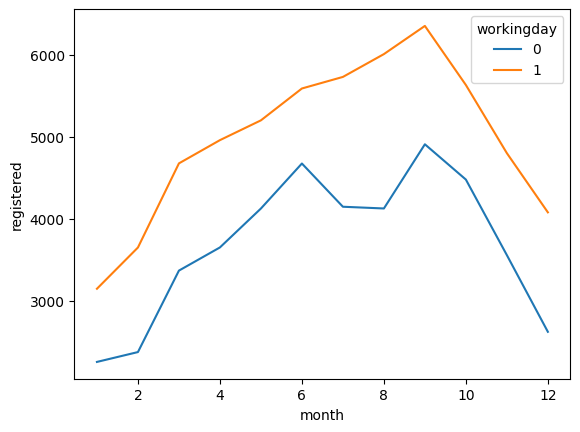

In [ ]:
sns.lineplot(data=bike_df, x='month', y='registered', errorbar=None, hue='workingday')
plt.show()

## (2) Bar Plot

In [ ]:
bike_df.head()

,month,day,quarter,day_of_week,workingday,holiday,temperature,humidity,windspeed,registered,casual,total
0,1,1,1Q,SUN,0,0,21.4,72,12,1608,686,2294
1,1,2,1Q,MON,0,1,15.0,44,19,1707,244,1951
2,1,3,1Q,TUE,1,0,7.6,39,23,2147,89,2236
3,1,4,1Q,WED,1,0,0.4,35,11,2273,95,2368
4,1,5,1Q,THU,1,0,14.2,49,6,3132,140,3272


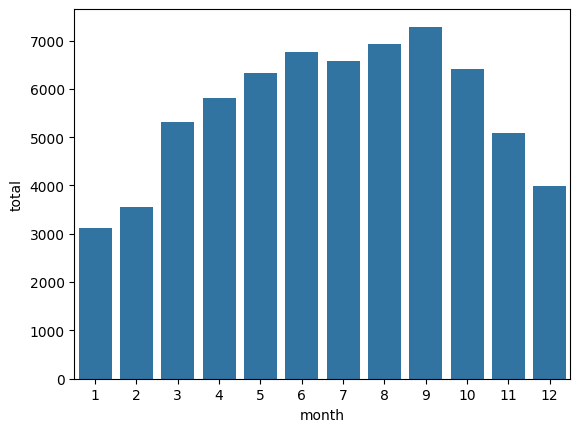

In [ ]:
sns.barplot(data=bike_df, x='month', y='total', errorbar=None)
plt.show()

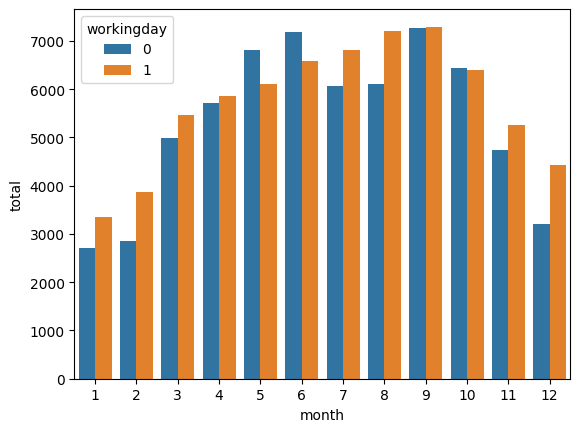

In [ ]:
sns.barplot(data=bike_df, x='month', y='total', errorbar=None, hue='workingday')
plt.show()

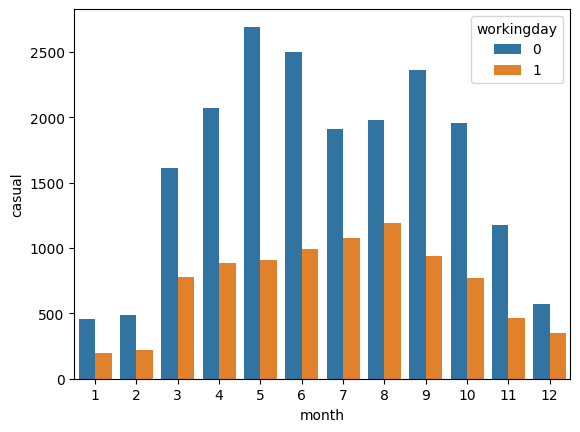

In [ ]:
sns.barplot(data=bike_df, x='month', y='casual', errorbar=None, hue='workingday')
plt.show()

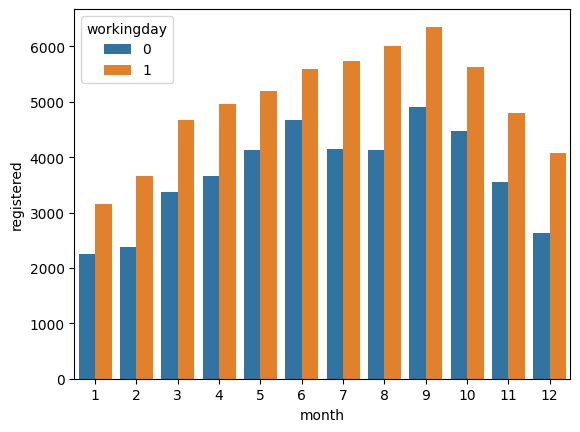

In [ ]:
sns.barplot(data=bike_df, x='month', y='registered', errorbar=None, hue='workingday')
plt.show()

## (3) Scatter Plot

- **정의** : 두 연속형 변수의 관계를 **좌표평면에 점으로 표시**하는 그래프
- **특징**
  - X축과 Y축 각각 하나의 변수 대응
  - 변수 간 상관관계(양/음, 강도) 시각화
  - 이상치(outlier) 탐지에 유용
  - `hue`, `style`, `size`로 추가 변수 시각화 가능
- **사용 상황**
  - 두 변수 사이의 관계 분석
  - 데이터의 분산 정도 및 패턴 확인

In [ ]:
bike_df = pd.read_csv("bike.csv")
bike_df.head()

,month,day,quarter,day_of_week,workingday,holiday,temperature,humidity,windspeed,registered,casual,total
0,1,1,1Q,SUN,0,0,21.4,72,12,1608,686,2294
1,1,2,1Q,MON,0,1,15.0,44,19,1707,244,1951
2,1,3,1Q,TUE,1,0,7.6,39,23,2147,89,2236
3,1,4,1Q,WED,1,0,0.4,35,11,2273,95,2368
4,1,5,1Q,THU,1,0,14.2,49,6,3132,140,3272


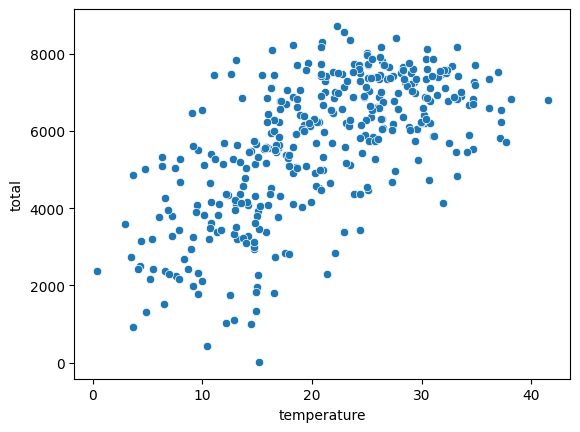

In [ ]:
sns.scatterplot(data=bike_df, x='temperature', y='total')
plt.show()

## (4) Regplot

- **정의** : 두 변수 간의 관계를 산점도와 함께 회귀선(Regression Line)으로 표현하는 그래프

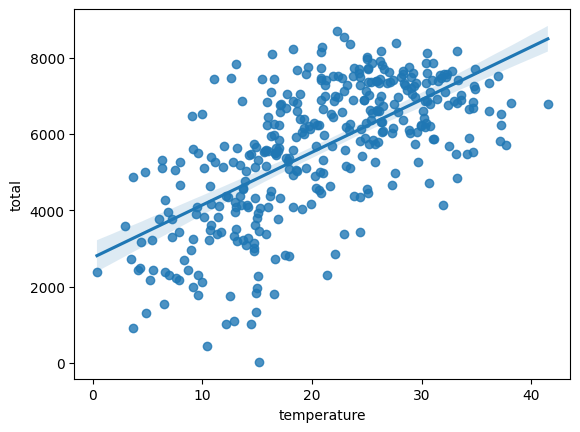

In [ ]:
# 기온과 자전거 전체 이용 건수와의 관계
sns.regplot(data=bike_df, x='temperature', y='total')
plt.show()

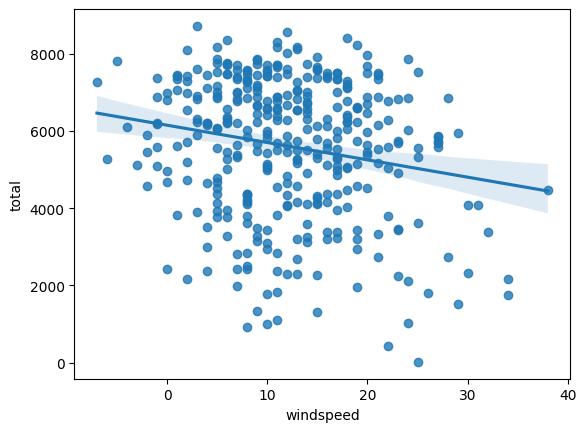

In [ ]:
# 풍속과 자전거 전체 이용 건수와의 관계
sns.regplot(data=bike_df, x='windspeed', y='total')
plt.show()

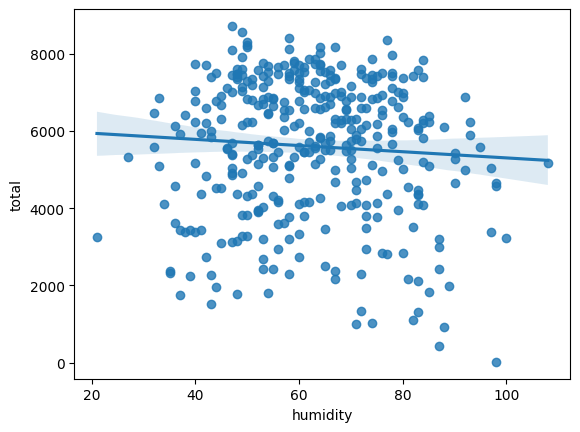

In [ ]:
# 습도와 자전거 전체 이용 건수와의 관계
sns.regplot(data=bike_df, x='humidity', y='total')
plt.show()

## (5) Box Plot

- **정의** : 데이터의 분포를 사분위수(Q1, Q3)와 중앙값(median)으로 표현하는 그래프

- **특징**
  - 박스(Box): Q1 ~ Q3(IQR, interquartile range)
  - 선(Whisker): 데이터의 전체 범위(보통 Q1-1.5 * IQR ~ Q3+1.5 * IQR)
  - 점(Point): 이상치(outlier)
  - 데이터의 대표값, 산포도, 이상치를 한눈에 파악 가능

- **사용 상황**
  - 그룹별 데이터 분포 비교
  - 이상치 탐지

In [47]:
bike_df.head()

,month,day,quarter,day_of_week,workingday,holiday,temperature,humidity,windspeed,registered,casual,total
0,1,1,1Q,SUN,0,0,21.4,72,12,1608,686,2294
1,1,2,1Q,MON,0,1,15.0,44,19,1707,244,1951
2,1,3,1Q,TUE,1,0,7.6,39,23,2147,89,2236
3,1,4,1Q,WED,1,0,0.4,35,11,2273,95,2368
4,1,5,1Q,THU,1,0,14.2,49,6,3132,140,3272


In [48]:
bike_df['day_of_week'].unique()

array(['SUN', 'MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT'], dtype=object)

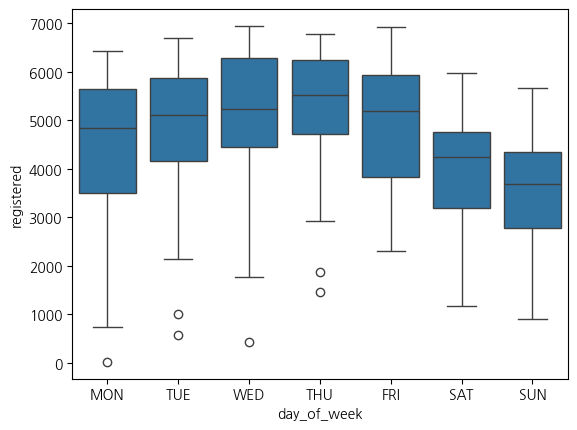

In [49]:
sns.boxplot(data=bike_df, x='day_of_week', y='registered', order=['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'])
plt.show()

## (6) Histplot

- **정의** : 연속형 데이터를 구간(bin)으로 나누어 각 구간에 속하는 데이터의 개수를 막대그래프로 표현

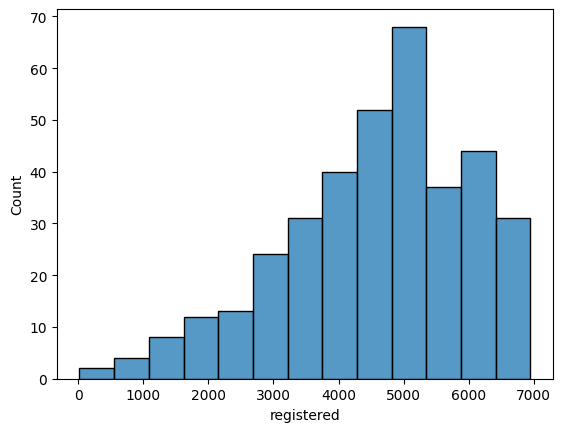

In [ ]:
sns.histplot(data=bike_df, x='registered')
plt.show()

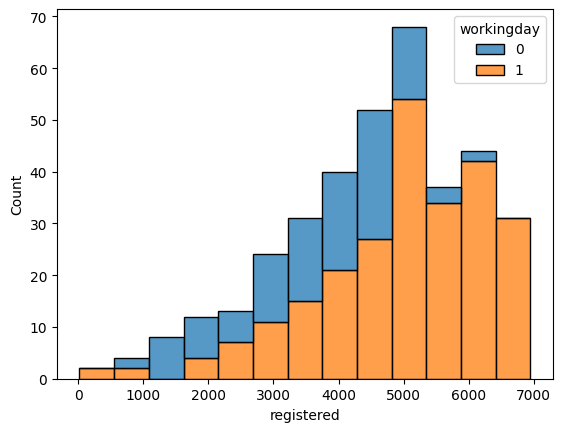

In [ ]:
sns.histplot(data=bike_df, x='registered', hue='workingday', multiple='stack') # 멀티플은 휴로 나눈 그룹을 어떻게 배치할지 결정하는 파라미터, 레이어면 겹쳐서, 스택이면 쌓아서 필이면 비율로
plt.show()

## (7) KDE Plot

- **정의** : 커널 밀도 추정(KDE, Kernel Density Estimation)을 이용해 **데이터의 분포를 연속적인 곡선**으로 표현한 그래프

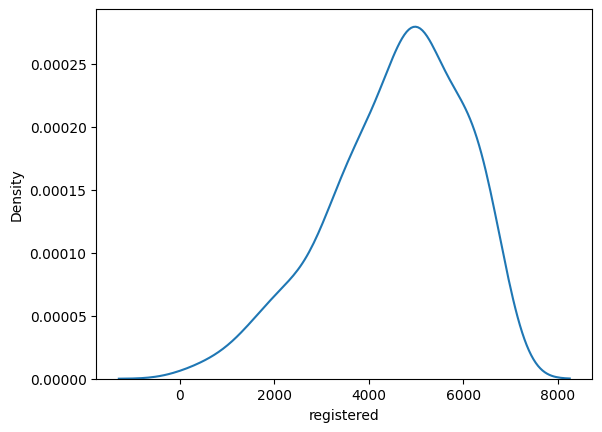

In [ ]:
sns.kdeplot(data=bike_df, x='registered')
plt.show()

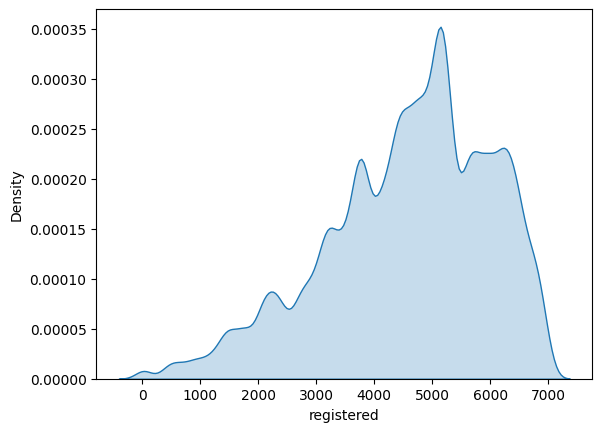

In [ ]:
sns.kdeplot(data=bike_df, x='registered', fill=True, bw_method=0.1)
plt.show()

## (8) Violin Plot

- **정의** : `boxplot`에 밀도 분포(KDE)를 더한 그래프

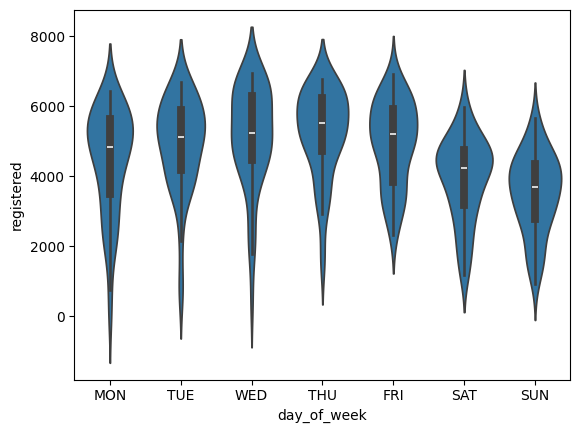

In [ ]:
sns.violinplot(data=bike_df, x='day_of_week', y='registered', order=['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'])
plt.show()

## (9) Stripplot

- **정의** : strip은 가느다란 조각이라는 뜻을 가지고 있고, 범주형 데이터의 분포를 점(개별 관측치)으로 표현하는 그래프

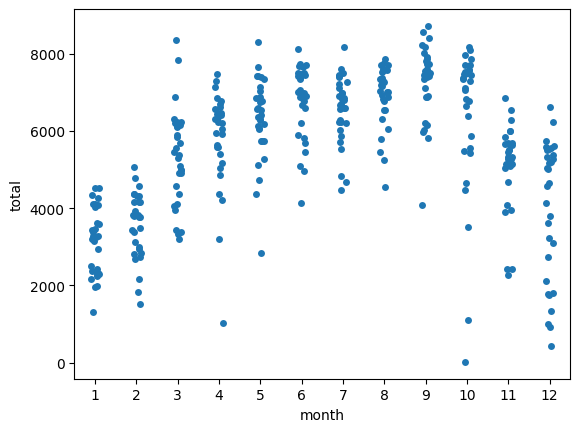

In [ ]:
sns.stripplot(data=bike_df, x='month', y='total')
plt.show()

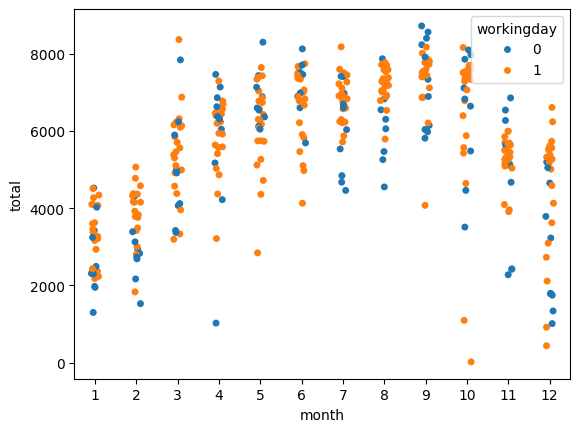

In [ ]:
sns.stripplot(data=bike_df, x='month', y='total', hue='workingday')
plt.show()

## (10) Swarmplot

- **정의** : 범주형 데이터의 분포를 점으로 표현하며, **데이터 포인트가 겹치지 않도록** 배치하는 그래프

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


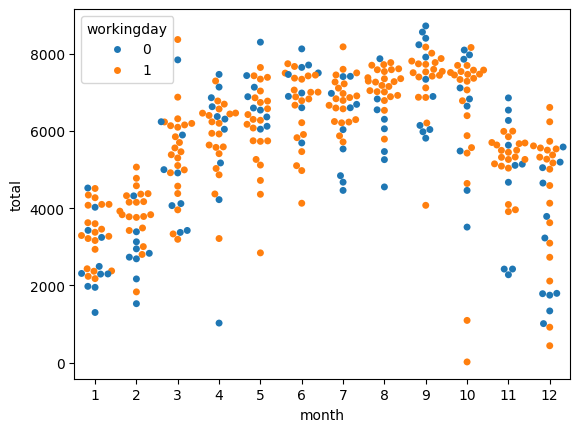

In [ ]:
sns.swarmplot(data=bike_df, x='month', y='total', hue='workingday')
plt.show()

## (11) Correlation Heatmap

- **산점도 (Scatter Plot)** : 두 변수 간의 관계를 점으로 표현
- **상관계수 (Correlation Coefficient)**
  - 상관계수: -1 ~ 1 범위
  - `> 0` → 양의 상관관계(한 변수가 커질수록 다른 변수도 커짐)
  - `= 0` → 두 변수 간 상관 없음
  - `< 0` → 음의 상관관계(한 변수가 커질수록 다른 변수는 작아짐)

In [ ]:
bike_df.head()

,month,day,quarter,day_of_week,workingday,holiday,temperature,humidity,windspeed,registered,casual,total
0,1,1,1Q,SUN,0,0,21.4,72,12,1608,686,2294
1,1,2,1Q,MON,0,1,15.0,44,19,1707,244,1951
2,1,3,1Q,TUE,1,0,7.6,39,23,2147,89,2236
3,1,4,1Q,WED,1,0,0.4,35,11,2273,95,2368
4,1,5,1Q,THU,1,0,14.2,49,6,3132,140,3272


In [ ]:
bike_df.corr(numeric_only=True)

,month,day,workingday,holiday,temperature,humidity,windspeed,registered,casual,total
month,1.000000,0.006443,-0.007513,0.006258,0.128435,0.191763,-0.043407,0.281855,0.099117,0.266502
day,0.006443,1.000000,0.022520,-0.031464,0.006938,0.092935,0.024777,-0.055827,-0.019697,-0.052814
workingday,-0.007513,0.022520,1.000000,-0.258418,0.029387,0.043649,-0.072115,0.437003,-0.539919,0.118884
holiday,0.006258,-0.031464,-0.258418,1.000000,-0.019713,-0.023121,0.057260,-0.164190,0.029720,-0.118134
temperature,0.128435,0.006938,0.029387,-0.019713,1.000000,0.087400,-0.114972,0.554088,0.477538,0.643860
humidity,0.191763,0.092935,0.043649,-0.023121,0.087400,1.000000,-0.221569,-0.049545,-0.066836,-0.067814
windspeed,-0.043407,0.024777,-0.072115,0.057260,-0.114972,-0.221569,1.000000,-0.182959,-0.104406,-0.189995
registered,0.281855,-0.055827,0.437003,-0.164190,0.554088,-0.049545,-0.182959,1.000000,0.274984,0.912994
casual,0.099117,-0.019697,-0.539919,0.029720,0.477538,-0.066836,-0.104406,0.274984,1.000000,0.643305
total,0.266502,-0.052814,0.118884,-0.118134,0.643860,-0.067814,-0.189995,0.912994,0.643305,1.000000


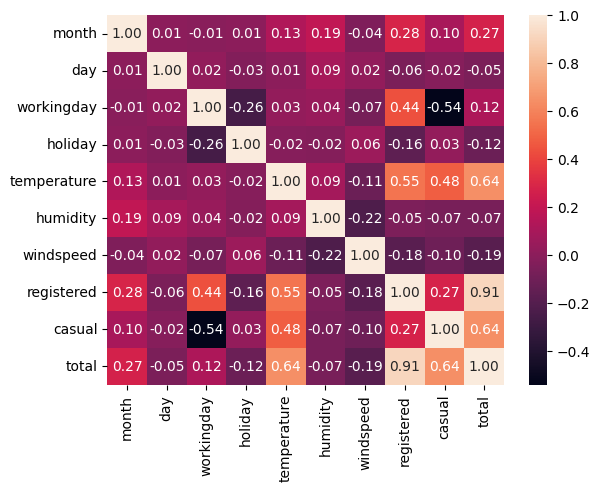

In [ ]:
sns.heatmap(bike_df.corr(numeric_only=True), annot=True, fmt='.2f') annot - 숫자표시할래말래 fmt- 소숫점 어디까지
plt.show()

# 데이터 시각화 심화

# [1] matplotlib

[matplotlib](https://matplotlib.org/stable/gallery/index.html?utm_source=chatgpt.com)

**matplotlib의 두 가지 인터페이스(interface, 동작 방식)**

1. Object-oriented(객체 지향적) : matplotlib의 기본 동작 원리로 그래프가 구성하는 각각의 요소들을 하나씩 구체적으로 짚어가며 구현한다. 세부적인 그래프의 조정에 유리하다.

2. State-based(상태 기반의) : object-oriented 방식에서 불필요해 보이는 코드가 조금씩 생략된 방식으로 꼭 필요한 코드가 아닌 부차적인 코드는 숨겨서 보다 편리한 사용성을 제공한다.

## (1) Object-oriented 방식

- Object-oriented(객체 지향적) : 그림 그릴 공간을 준비한 후, 그곳에 캔버스를 얹고, 그 캔버스 위에 그림을 그리는 방식으로 진행한다.

**Figure와 Axes**

- Object-oriented는 그림을 그릴 공간(figure)을 준비한 후, 그곳에 캔버스(axes)를 얹고, 그 캔버스 위에 그림을 그리는 방식으로 진행한다.
  - Figure : 그래프를 담고 있는 최상위 객체로 그래프가 그려질 빈 공간이다.
  - Axes : Figure 안에 들어가는 하위 개념으로 그래프가 들어가는 빈 영역이다. 하나의 캔버스에는 하나의 작품이 그려지는 것처럼 Axes에는 그래프를 하나만 얹을 수 있다.

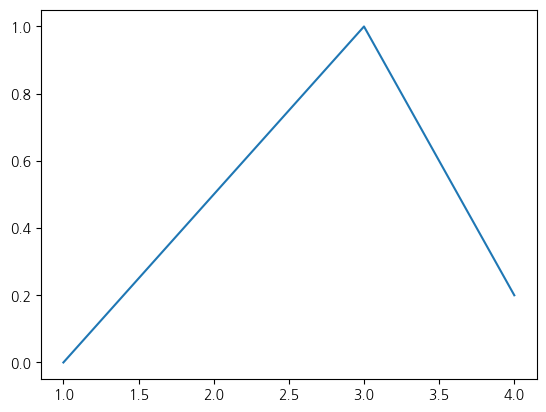

In [51]:
fig, ax = plt.subplots()  # fig : 그림을 그릴 공간, ax : 캔버스
ax.plot([1, 2, 3, 4], [0, 0.5, 1, 0.2])  # 캔버스(ax) 위에 그래프 그리기
plt.show()

### (a) Line Plot

In [52]:
# 2011년부터 2020년까지의 애플 주가 데이터
year_array = np.array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020])
stock_array = np.array([14.46, 19.01, 20.04, 27.59, 26.32, 28.96, 42.31, 39.44, 73.41, 132.69])

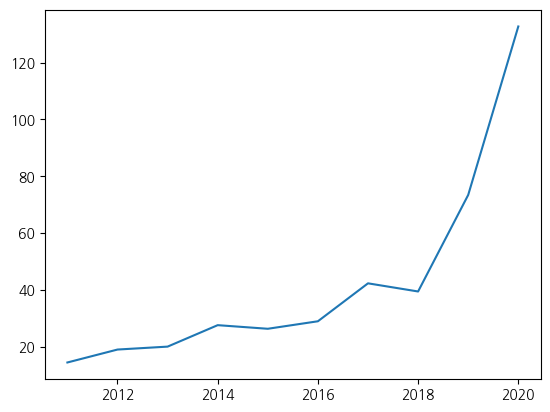

In [53]:
# Figure와 Axes 생성
fig, ax = plt.subplots()
ax.plot(year_array, stock_array)
plt.show()

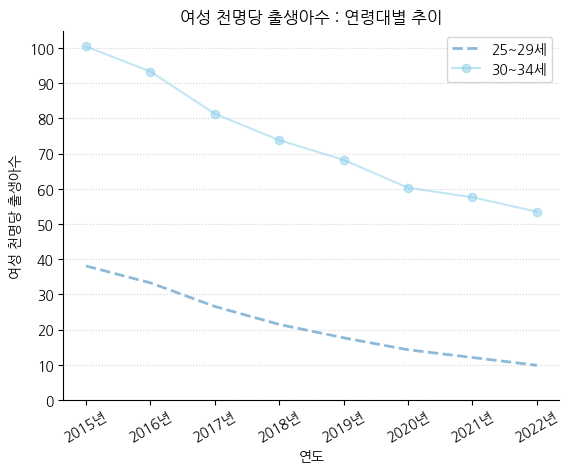

In [54]:
# 데이터 불러오기
birth_df = pd.read_csv('birth_rate.csv')
birth_df.head()

,지역,시점,연령대,여성 천명당 출생아수
0,서울특별시,2015,15-19세,1.0
1,서울특별시,2015,20-24세,6.4
2,서울특별시,2015,25-29세,38.1
3,서울특별시,2015,30-34세,100.4
4,서울특별시,2015,35-39세,49.6


In [55]:
birth_df['연령대'].unique()

array(['15-19세', '20-24세', '25-29세', '30-34세', '35-39세', '40-44세',
       '45-49세'], dtype=object)

In [56]:
# 25-29세만 데이터 필터링
birth_25_29 = birth_df.query("연령대 == '25-29세'")

In [57]:
# 30-34세만 데이터 필터링
birth_30_34 = birth_df.query("연령대 == '30-34세'")

In [58]:
birth_25_29

,지역,시점,연령대,여성 천명당 출생아수
2,서울특별시,2015,25-29세,38.1
9,서울특별시,2016,25-29세,33.3
16,서울특별시,2017,25-29세,26.6
23,서울특별시,2018,25-29세,21.5
30,서울특별시,2019,25-29세,17.7
37,서울특별시,2020,25-29세,14.3
44,서울특별시,2021,25-29세,12.1
51,서울특별시,2022,25-29세,9.9


In [59]:
birth_30_34

,지역,시점,연령대,여성 천명당 출생아수
3,서울특별시,2015,30-34세,100.4
10,서울특별시,2016,30-34세,93.3
17,서울특별시,2017,30-34세,81.3
24,서울특별시,2018,30-34세,73.8
31,서울특별시,2019,30-34세,68.2
38,서울특별시,2020,30-34세,60.3
45,서울특별시,2021,30-34세,57.6
52,서울특별시,2022,30-34세,53.5


In [60]:
#!pip install koreanize-matplotlib

In [61]:
import koreanize_matplotlib

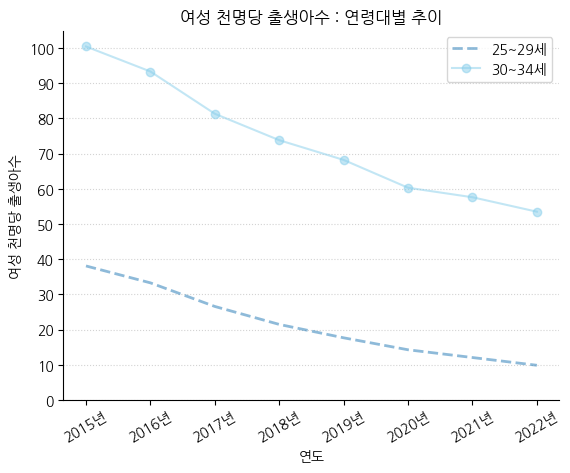

In [62]:
# Line Plot 시각화
fig, ax = plt.subplots()

ax.plot(birth_25_29['시점'], birth_25_29['여성 천명당 출생아수'], label='25~29세', alpha=0.5, linewidth=2, linestyle='--')
ax.plot(birth_30_34['시점'], birth_30_34['여성 천명당 출생아수'], label='30~34세', alpha=0.5, color='skyblue', marker='o')

ax.legend() # 범례

ax.set_title('여성 천명당 출생아수 : 연령대별 추이')
ax.set_xlabel('연도')
ax.set_ylabel('여성 천명당 출생아수')

ax.set_xticks(birth_25_29['시점'], labels=[f"{i}년" for i in birth_25_29['시점']], rotation=30)
ax.set_yticks(np.arange(0, 110, 10))

#ax.spines.top.set_visible(False)
#ax.spines.right.set_visible(False)
ax.spines[['top', 'right']].set_visible(False)

ax.grid(axis='y', linestyle=':', color='lightgrey')
plt.show()

(한 화면에 여러 개의 그래프 그리기)

**두 개의 Axes 다루기**

In [63]:
sns_df = pd.read_csv('social_media_stocks.csv')
sns_df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2012-05-18,FB,38.230000,38.230000,45.000000,38.000000,42.049999,573576400.0
1,2012-05-21,FB,34.029999,34.029999,36.660000,33.000000,36.529999,168192700.0
2,2012-05-22,FB,31.000000,31.000000,33.590000,30.940001,32.610001,101786600.0
3,2012-05-23,FB,32.000000,32.000000,32.500000,31.360001,31.370001,73600000.0
4,2012-05-24,FB,33.029999,33.029999,33.209999,31.770000,32.950001,50237200.0


In [64]:
sns_df['Symbol'].unique()

array(['FB', 'TWTR', 'ETSY', 'SNAP', 'PINS'], dtype=object)

In [65]:
sns_df.dtypes

,0
Date,object
Symbol,object
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,float64


In [66]:
sns_df['Date'] = pd.to_datetime(sns_df['Date'])

In [67]:
sns_df['Year'] = sns_df['Date'].dt.year

In [68]:
sns_df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,Year
0,2012-05-18,FB,38.230000,38.230000,45.000000,38.000000,42.049999,573576400.0,2012
1,2012-05-21,FB,34.029999,34.029999,36.660000,33.000000,36.529999,168192700.0,2012
2,2012-05-22,FB,31.000000,31.000000,33.590000,30.940001,32.610001,101786600.0,2012
3,2012-05-23,FB,32.000000,32.000000,32.500000,31.360001,31.370001,73600000.0,2012
4,2012-05-24,FB,33.029999,33.029999,33.209999,31.770000,32.950001,50237200.0,2012


In [69]:
# 연도별 기업별 평균 주식 종가
sns_close_df = sns_df.groupby(['Year', 'Symbol'])['Close'].mean().reset_index()

In [70]:
sns_close_df.head()

,Year,Symbol,Close
0,2012,FB,24.673097
1,2013,FB,35.481151
2,2013,TWTR,49.657568
3,2014,FB,68.762341
4,2014,TWTR,45.451508


In [71]:
# Facebook(FB)과 Twitter(TWTR) 데이터 필터링
fb_stock_close = sns_close_df.query("Symbol == 'FB'")
twtr_stock_close = sns_close_df.query("Symbol == 'TWTR'")

In [72]:
twtr_stock_close.head(1)

,Year,Symbol,Close
2,2013,TWTR,49.657568


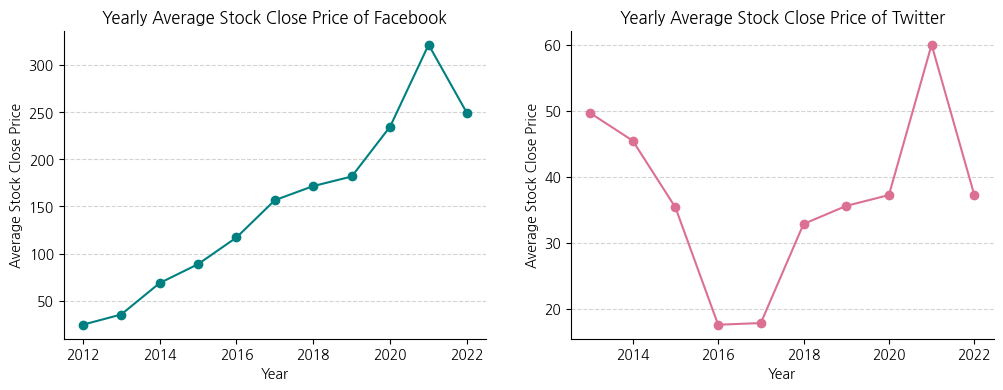

In [73]:
# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1 : Facebook의 연도별 평균 주식 종가
ax1.plot(fb_stock_close['Year'], fb_stock_close['Close'], color='teal', marker='o')

# ax2 : Twitter의 연도별 평균 주식 종가
ax2.plot(twtr_stock_close['Year'], twtr_stock_close['Close'], color='palevioletred', marker='o')

# ax1 : 그래프 커스터마이징
ax1.set_title('Yearly Average Stock Close Price of Facebook')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Stock Close Price')
ax1.grid(axis='y', linestyle='--', color='lightgrey')
ax1.spines[['top', 'right']].set_visible(False)

# ax2 : 그래프 커스터마이징
ax2.set_title('Yearly Average Stock Close Price of Twitter')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Stock Close Price')
ax2.grid(axis='y', linestyle='--', color='lightgrey')
ax2.spines[['top', 'right']].set_visible(False)

plt.show()

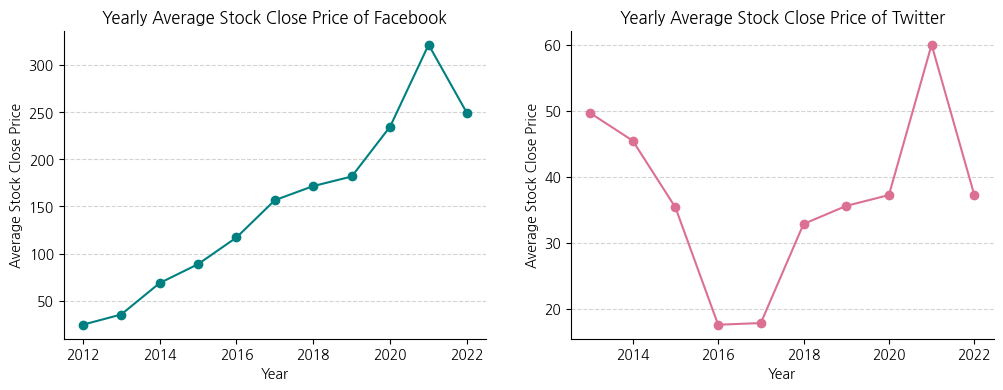

In [74]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ax1 : Facebook의 연도별 평균 주식 종가
axes[0].plot(fb_stock_close['Year'], fb_stock_close['Close'], color='teal', marker='o')

# ax2 : Twitter의 연도별 평균 주식 종가
axes[1].plot(twtr_stock_close['Year'], twtr_stock_close['Close'], color='palevioletred', marker='o')

# 제목 설정하기
axes[0].set_title('Yearly Average Stock Close Price of Facebook')
axes[1].set_title('Yearly Average Stock Close Price of Twitter')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Stock Close Price')
    ax.grid(axis='y', linestyle='--', color='lightgrey')
    ax.spines[['top', 'right']].set_visible(False)

plt.show()

**세 개의 Axes 다루기 & 축 공유**

In [75]:
sns_close_df.head()

,Year,Symbol,Close
0,2012,FB,24.673097
1,2013,FB,35.481151
2,2013,TWTR,49.657568
3,2014,FB,68.762341
4,2014,TWTR,45.451508


In [76]:
sns_close_df['Symbol'].unique()

array(['FB', 'TWTR', 'ETSY', 'SNAP', 'PINS'], dtype=object)

In [77]:
# Facebook(FB)과 Twitter(TWTR) 데이터 필터링
#fb_stock_close = sns_close_df.query("Symbol == 'FB'")
#twtr_stock_close = sns_close_df.query("Symbol == 'TWTR'")

In [78]:
# SNAP 데이터 필터링
snap_stock_close = sns_close_df.query("Symbol == 'SNAP'")

In [79]:
snap_stock_close.head(1)

,Year,Symbol,Close
13,2017,SNAP,17.00455


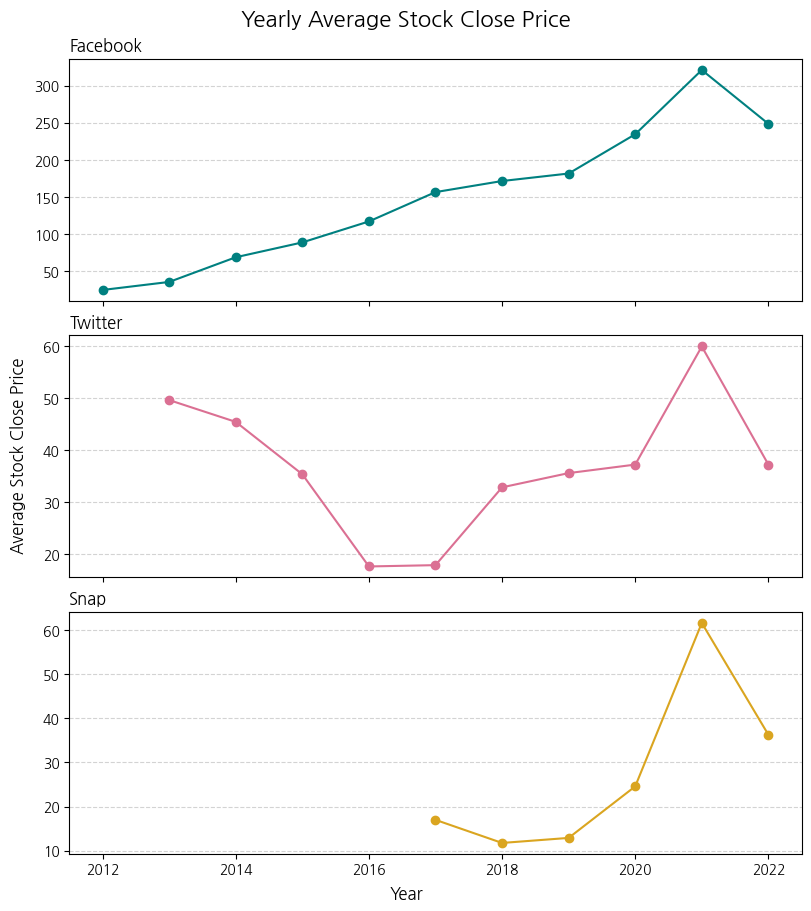

In [80]:
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, figsize=(8, 9), constrained_layout=True)  # sharex=True : x축 공유, constrained_layout=True : 그래프 간 간격 조정

# ax1 : Facebook의 연도별 평균 주식 종가
ax1.plot(fb_stock_close['Year'], fb_stock_close['Close'], color='teal', marker='o')

# ax2 : Twitter의 연도별 평균 주식 종가
ax2.plot(twtr_stock_close['Year'], twtr_stock_close['Close'], color='palevioletred', marker='o')

# ax3 : Snap의 연도별 평균 주식 종가
ax3.plot(snap_stock_close['Year'], snap_stock_close['Close'], color='goldenrod', marker='o')

# Figure 차원의 전체 제목, x축 이름, y축 이름
fig.suptitle('Yearly Average Stock Close Price', fontsize=16)
fig.supxlabel('Year')
fig.supylabel('Average Stock Close Price')

# ax1 : 그래프 커스터마이징
ax1.set_title('Facebook', loc='left')
ax1.grid(axis='y', linestyle='--', color='lightgrey')

# ax2 : 그래프 커스터마이징
ax2.set_title('Twitter', loc='left')
ax2.grid(axis='y', linestyle='--', color='lightgrey')

# ax3 : 그래프 커스터마이징
ax3.set_title('Snap', loc='left')
ax3.grid(axis='y', linestyle='--', color='lightgrey')

plt.show()

### (b) Bar Plot

In [81]:
# 학생별 반장선거 득표수 데이터
name_array = np.array(['A', 'B', 'C', 'D', 'E'])
votes_array = np.array([5, 10, 6, 8, 3])

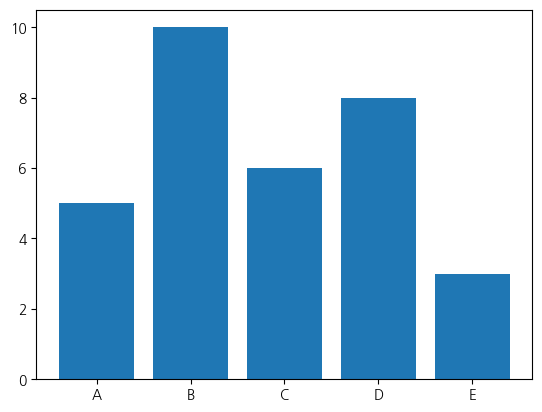

In [82]:
# 시각화
fig, ax = plt.subplots()

ax.bar(name_array, votes_array)
plt.show()

### (c) Scatter Plot

In [83]:
# 사람들의 키와 몸무게 데이터
height_array = np.array([165, 164, 155, 151, 157, 162, 155, 157, 165, 162, 165, 167, 167, 183, 180, 184, 177, 178, 175, 181, 172, 173, 169, 172, 177, 178, 185, 186, 190, 187])
weight_array = np.array([62, 59, 57, 55, 60, 58, 51, 56, 68, 64, 57, 58, 64, 79, 73, 76, 61, 65, 83, 80, 67, 82, 88, 62, 61, 79, 81, 68, 83, 80])

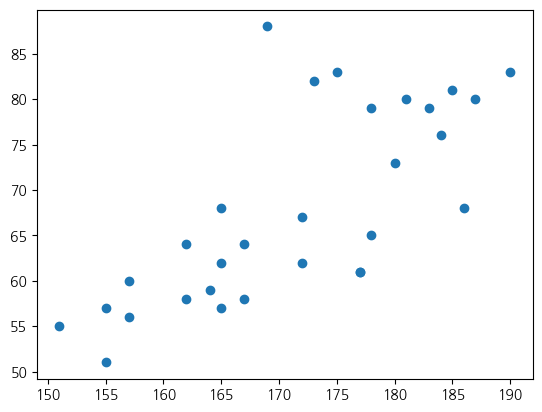

In [84]:
# 시각화
fig, ax = plt.subplots()

ax.scatter(height_array, weight_array)
plt.show()

## (2) State-based 방식

- State-based (상태 기반의) : 이미 그래프를 그릴 캔버스는 눈앞에 있다고 가정하고 바로 그래프를 그려버리는 방식이다.

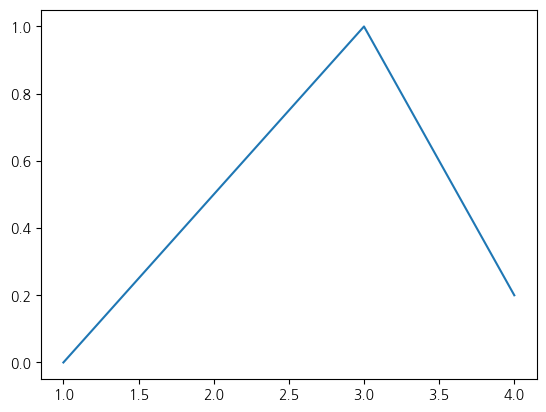

In [85]:
plt.plot([1, 2, 3, 4], [0, 0.5, 1, 0.2])
plt.show()

**Object-oriented 인터페이스 vs. State-based 인터페이스**

- 복잡하고 정교한 작업이 필요할수록 Objected-oriented 방식이 권장된다. 그 이유는, State-based 방식은 여러 그래프를 그릴 경우, plt.subplot()을 매번 반복적으로 적어줘야 한다.

1) Object-oriented 인터페이스

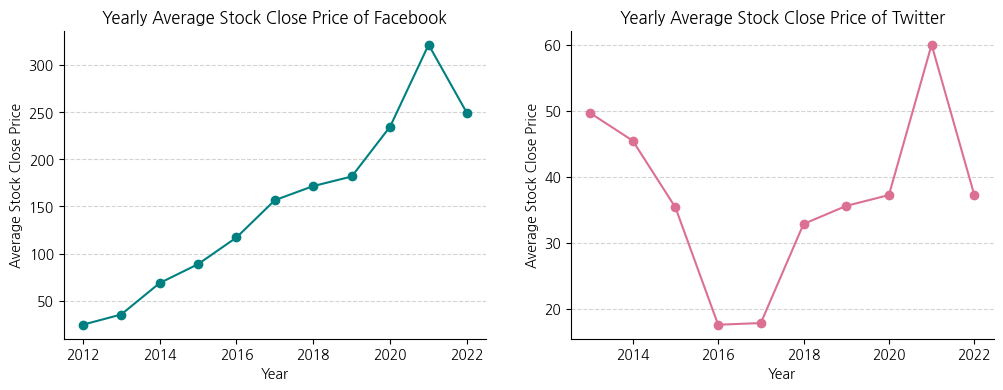

In [86]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ax1 : Facebook의 연도별 평균 주식 종가
axes[0].plot(fb_stock_close['Year'], fb_stock_close['Close'], color='teal', marker='o')

# ax2 : Twitter의 연도별 평균 주식 종가
axes[1].plot(twtr_stock_close['Year'], twtr_stock_close['Close'], color='palevioletred', marker='o')

# 제목 설정하기
axes[0].set_title('Yearly Average Stock Close Price of Facebook')
axes[1].set_title('Yearly Average Stock Close Price of Twitter')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Stock Close Price')
    ax.grid(axis='y', linestyle='--', color='lightgrey')
    ax.spines[['top', 'right']].set_visible(False)

plt.show()

2) State-based 인터페이스

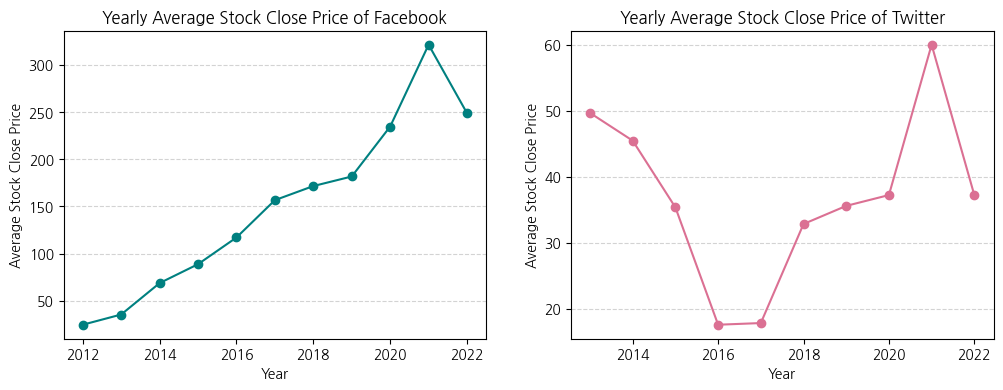

In [87]:
plt.figure(figsize=(12, 4))

# 좌측 : Facebook의 연도별 평균 주식 종가
plt.subplot(1, 2, 1)
plt.plot(fb_stock_close['Year'], fb_stock_close['Close'], color='teal', marker='o')

plt.title('Yearly Average Stock Close Price of Facebook')
plt.xlabel('Year')
plt.ylabel('Average Stock Close Price')
plt.grid(axis='y', linestyle='--', color='lightgrey')

# 우측 : Twitter의 연도별 평균 주식 종가
plt.subplot(1, 2, 2)
plt.plot(twtr_stock_close['Year'], twtr_stock_close['Close'], color='palevioletred', marker='o')

plt.title('Yearly Average Stock Close Price of Twitter')
plt.xlabel('Year')
plt.ylabel('Average Stock Close Price')
plt.grid(axis='y', linestyle='--', color='lightgrey')

plt.show()

# [2] seaborn

[seaborn](https://seaborn.pydata.org/examples/index.html?utm_source=chatgpt.com)

**Figure-level과 Axes-level 함수**

- Seaborn은 Figure-level과 Axes-level이라 불리는 두 가지 타입의 함수를 지원한다. Figure-level 함수는 하나에 여러 개의 Axes-level 함수가 대응되는 1:N의 관계가 있다.

| **Plot Type** | **Subplots**                                                  |
| ------------- | ------------------------------------------------------------- |
| **catplot**   | barplot, countplot, stripplot, boxplot, violinplot, swarmplot, pointplot |
| **relplot**   | scatterplot, lineplot                                         |
| **displot**   | histplot, kdeplot, ecdfplot                          |

## (1) Figure-level 그래프

### (a) catplot

- catplot은 categorical plot의 줄임말로 카테고리별 수치 비교 목적의 시각화에 적합한 함수이다. Figure-level 함수들은 `sns.catplot(kind='bar')`와 같은 방식으로 다양한 종류의 시각화를 지원하는데, catplot의 kind 파라미터에 넣을 수 있는 옵션은 총 8가지가 있다.
  - bar, count, strip, box, violin, swarm, boxen, point
  

1. Bar Plot

In [ ]:
customer_df = pd.read_csv('customer_personality.csv', sep='\t')
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
customer_df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [ ]:
# 일부 Marital_Status만 사용('Single', 'Together', 'Married', 'Divorced')
temp = customer_df.query("Marital_Status in ['Single', 'Together', 'Married', 'Divorced']").copy()

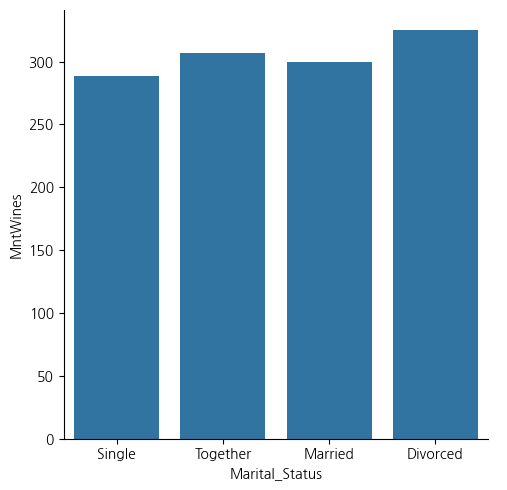

In [ ]:
sns.catplot(data=temp, x='Marital_Status', y='MntWines', kind='bar', errorbar=None)
plt.show()

In [ ]:
customer_df['Kidhome'].unique()

array([0, 1, 2])

In [ ]:
# Kids : 아이 유무(Yes, No)
temp['Kids'] = 'No'
temp.loc[temp['Kidhome'] >= 1, 'Kids'] = 'Yes'

In [ ]:
temp.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Kids
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,0,3,11,1,No
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,0,3,11,0,Yes
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,0,3,11,0,No
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,0,3,11,0,Yes
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,0,3,11,0,Yes


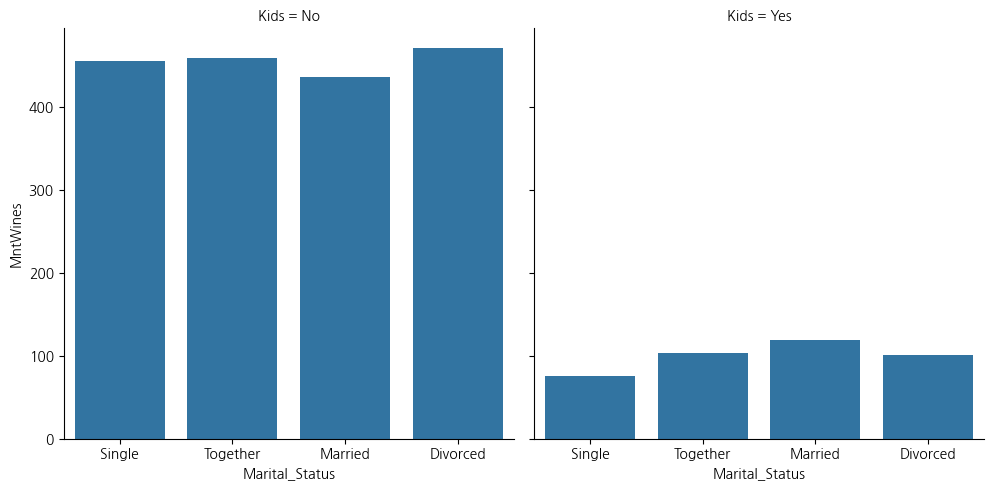

In [ ]:
sns.catplot(data=temp, x='Marital_Status', y='MntWines', col='Kids', kind='bar', errorbar=None)
plt.show()

2. Count Plot

3. Strip Plot

4. Box Plot

5. Violin Plot

### (b) relplot

- relplot은 relational plot의 줄임말로 두 연속형 변수 사이의 관계를 나타내는 데 적합한 함수이다.
  - scatter, line

1. Scatter Plot

In [ ]:
exam_df = pd.read_csv('student_exam.csv')
exam_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
exam_df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

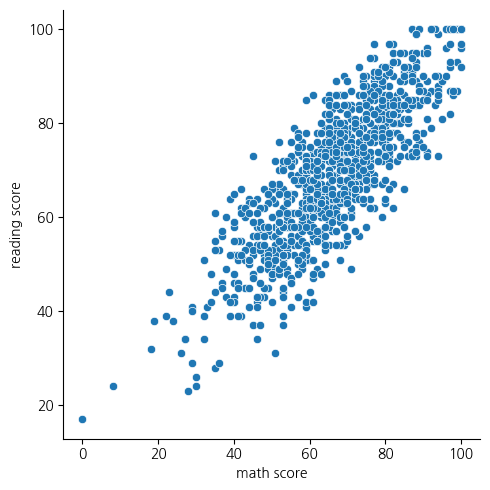

In [ ]:
sns.relplot(data=exam_df, x='math score', y='reading score', kind='scatter')
plt.show()

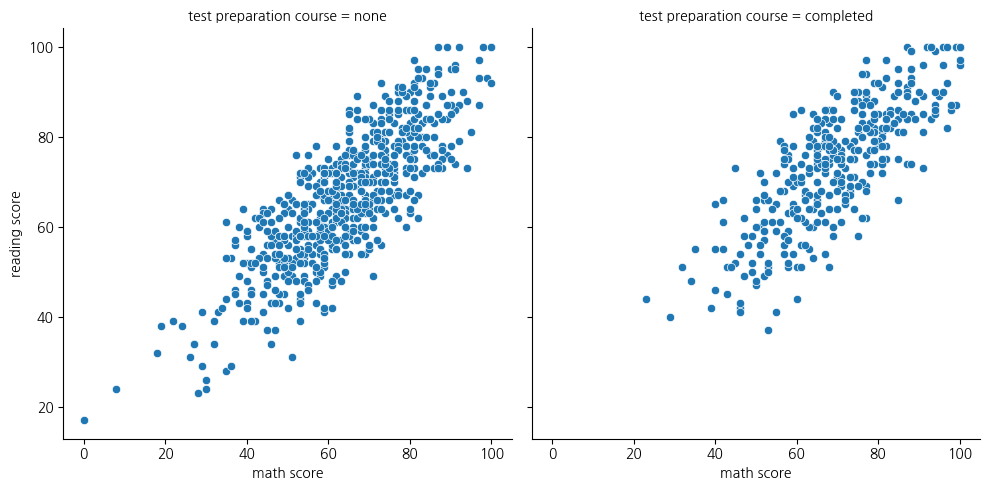

In [ ]:
sns.relplot(data=exam_df, x='math score', y='reading score', col='test preparation course', kind='scatter')
plt.show()

2. Line Plot

In [ ]:
books_df = pd.read_csv('amazon_bestsellers.csv')
books_df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


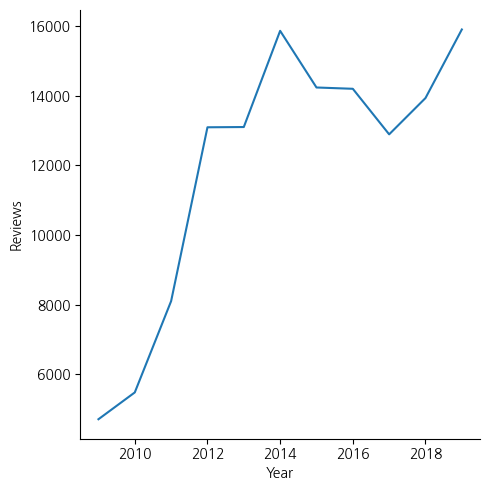

In [ ]:
sns.relplot(data=books_df, x='Year', y='Reviews', kind='line', errorbar=None)
plt.show()

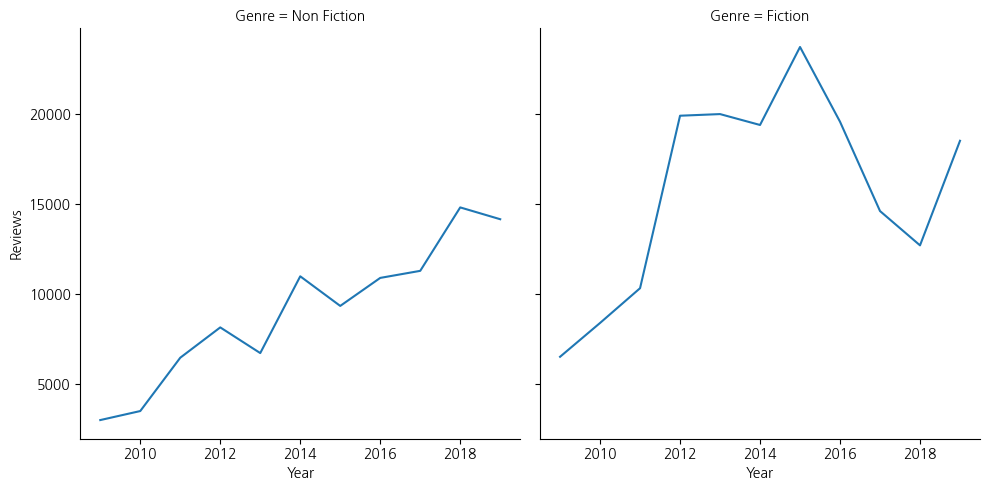

In [ ]:
sns.relplot(data=books_df, x='Year', y='Reviews', col='Genre', kind='line', errorbar=None)
plt.show()

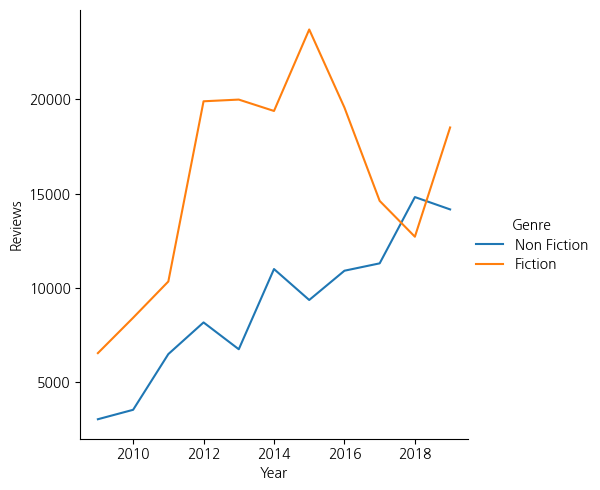

In [ ]:
sns.relplot(data=books_df, x='Year', y='Reviews', hue='Genre', kind='line', errorbar=None)
plt.show()

### (c) displot

- displot은 distribution plot의 줄임말이다.
  - hist, kde, ecdf(Empirical Cumulative Distribution Function)

1. Histogram

In [ ]:
exam_df = pd.read_csv('student_exam.csv')
exam_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


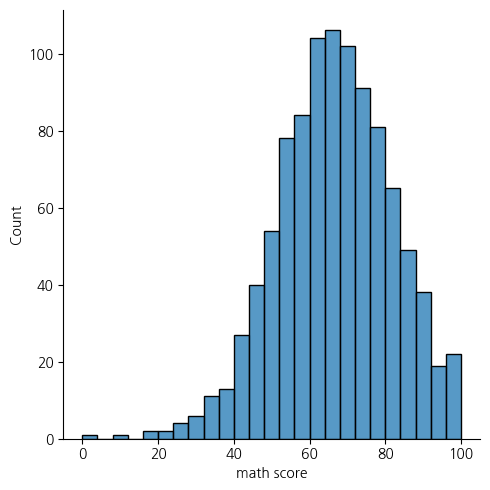

In [ ]:
sns.displot(data=exam_df, x='math score', kind='hist')  # bins=10 : 구간의 수
plt.show()

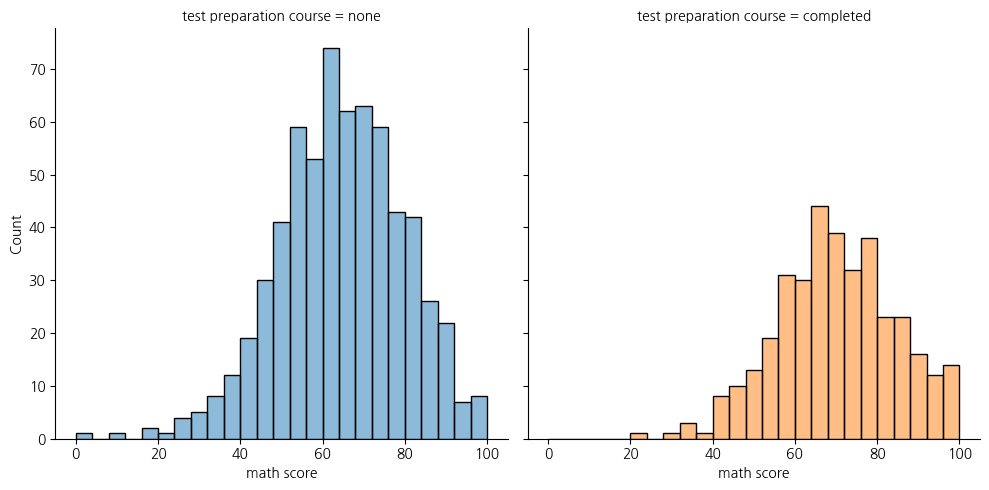

In [ ]:
sns.displot(data=exam_df, x='math score', col='test preparation course', hue='test preparation course', kind='hist', legend=False)
plt.show()


2. KDE Plot

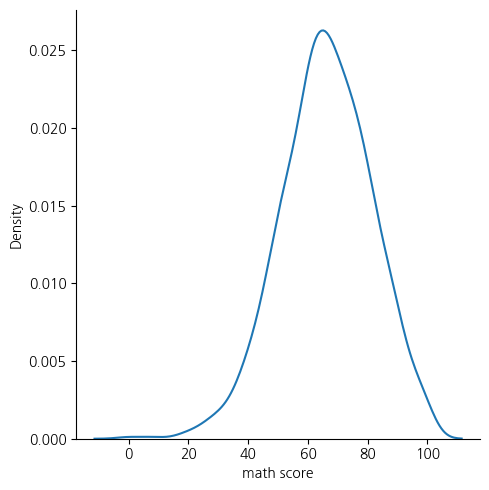

In [ ]:
sns.displot(data=exam_df, x='math score', kind='kde')
plt.show()

3. Histogram + KDE Plot

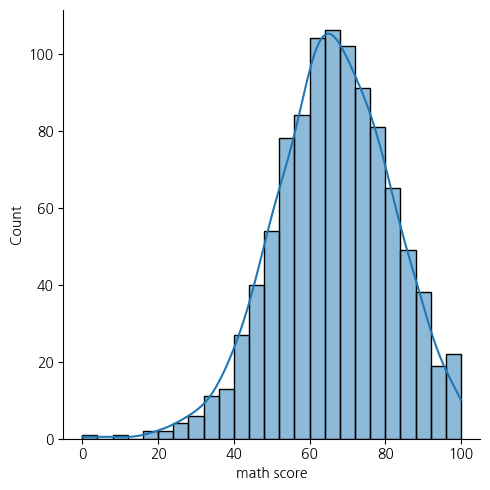

In [ ]:
sns.displot(data=exam_df, x='math score', kind='hist', kde=True)
plt.show()

4. 두 개의 변수로 분포 시각화하기

In [ ]:
exam_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


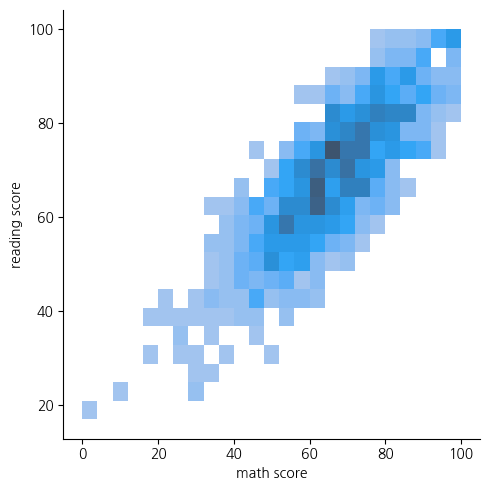

In [ ]:
sns.displot(data=exam_df, x='math score', y='reading score', kind='hist')

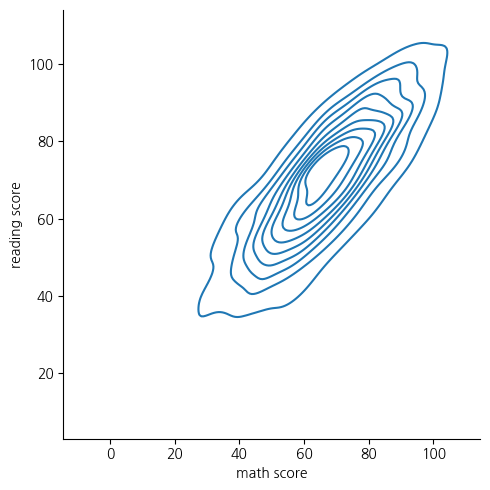

In [ ]:
sns.displot(data=exam_df, x='math score', y='reading score', kind='kde')

## (2) Axes-level 그래프

**Figure-level vs Axes-level**

- Figure-level 함수 : col, row 파라미터로 그룹별 그래프를 손쉽게 분리해 그릴 수 있어 데이터를 쪼개보며 인사이트를 찾고 싶을 때 사용하기 좋은 선택지이다.
- Axes-level 함수 : 더 직관적이고 명료하고 matplotlib 기반의 추가 가공이 쉽다.

**막대 그래프**

In [ ]:
customer_df = pd.read_csv('customer_personality.csv', sep='\t')
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# 일부 Marital_Status만 사용('Single', 'Together', 'Married', 'Divorced')
temp = customer_df.query("Marital_Status in ['Single', 'Together', 'Married', 'Divorced']").copy()

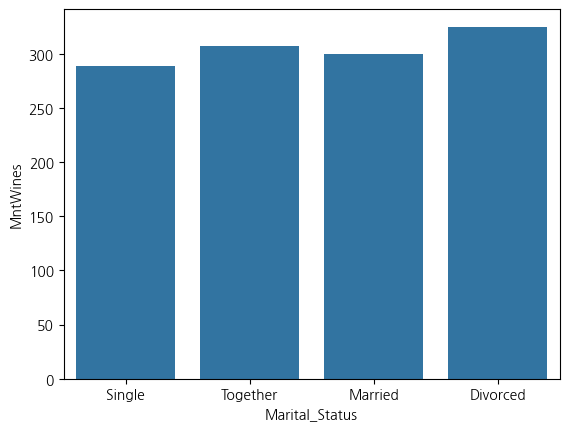

In [ ]:
sns.barplot(data=temp, x='Marital_Status', y='MntWines', errorbar=None)
plt.show()

(값의 순서 조정하기) 막대 그래프의 값 순서를 바꾸기 위해서는 order 파라미터에 list 형태로 원하는 순서를 넣어주면 된다.

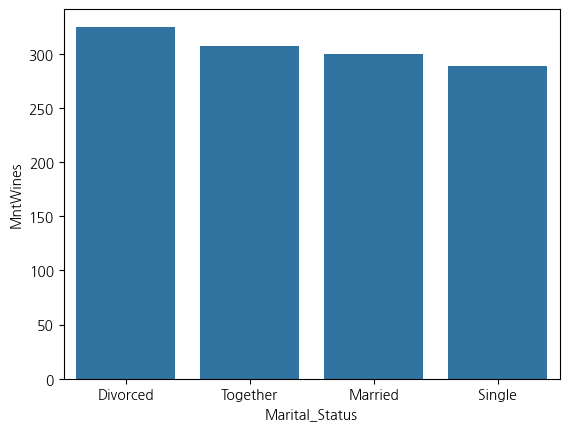

In [ ]:
sns.barplot(data=temp,
            x='Marital_Status',
            y='MntWines',
            order=['Divorced', 'Together', 'Married', 'Single'],
            errorbar=None)
plt.show()

(Estimator 변경하기) Seaborn의 barplot은 기본적으로 지표를 평균값 기준으로 요약해서 보여주도록 세팅(기본 옵션 : estimator='mean')되어있는데, 다른 지표를 기준으로 계산이 가능하다. 예를 들어, 중앙값 지표를 기준으로 변경하겠다.

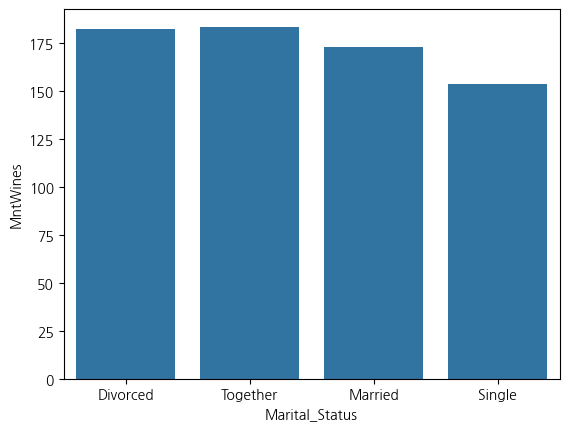

In [ ]:
sns.barplot(data=temp,
            x='Marital_Status',
            y='MntWines',
            order=['Divorced', 'Together', 'Married', 'Single'],
            errorbar=None,
            estimator='median')
plt.show()

(그래프 꾸미기) Seaborn 그래프 함수들은 모두 palette 파라미터를 보유하고 있어서 그래프를 원하는 테마의 색 조합으로 칠할 수 있다.

[Palette](https://seaborn.pydata.org/tutorial/color_palettes.html)

/tmp/ipykernel_63535/963437896.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp,


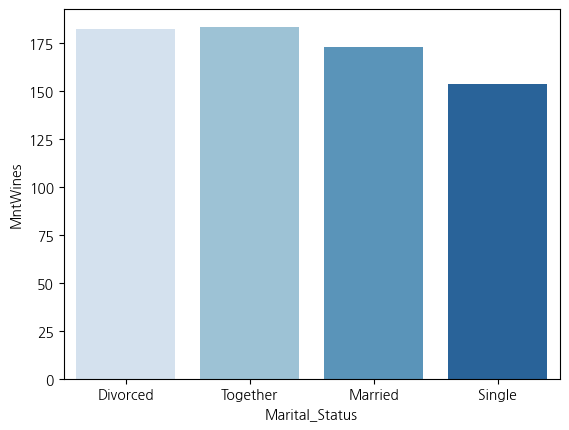

In [ ]:
sns.barplot(data=temp,
            x='Marital_Status',
            y='MntWines',
            order=['Divorced', 'Together', 'Married', 'Single'],
            errorbar=None,
            estimator='median',
            palette='Blues')
plt.show()

Seaborn에서 사용 가능한 대부분의 팔레트에는 _d와 _r이라는 접미사를 붙일 수 있다.
* Blues_d : _d가 붙으면 dark 버전의 팔레트
* Blues_r : _r가 붙으면 reversed 버전의 팔레트

/tmp/ipykernel_63535/3167831069.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp,


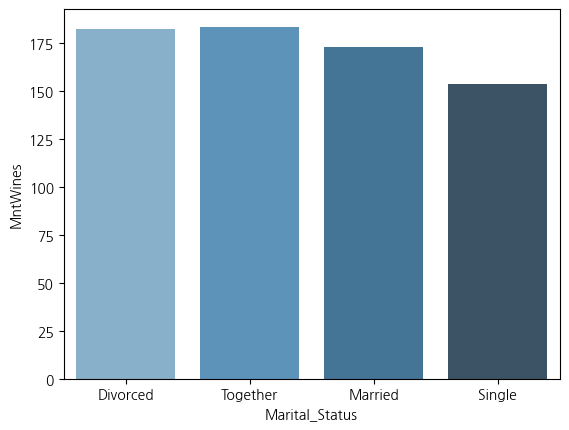

In [ ]:
sns.barplot(data=temp,
            x='Marital_Status',
            y='MntWines',
            order=['Divorced', 'Together', 'Married', 'Single'],
            errorbar=None,
            estimator='median',
            palette='Blues_d')
plt.show()

/tmp/ipykernel_63535/2367948981.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp,


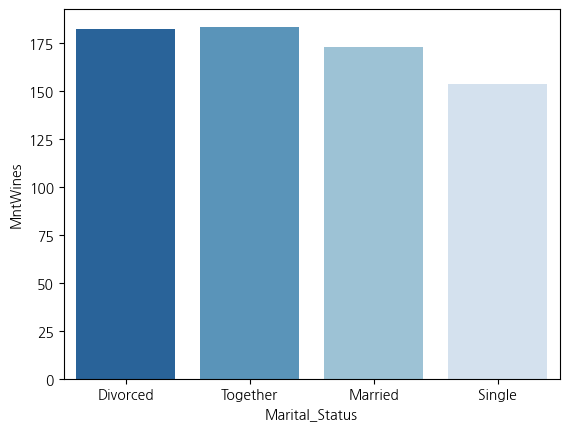

In [ ]:
sns.barplot(data=temp,
            x='Marital_Status',
            y='MntWines',
            order=['Divorced', 'Together', 'Married', 'Single'],
            errorbar=None,
            estimator='median',
            palette='Blues_r')
plt.show()

## 커스터마이징하기

### (1) seaborn으로 커스터마이징

1. Spine 제거하기
2. 범례 옮기기
3. 전체 그래프 설정 변경하기
4. 평균선 추가하기

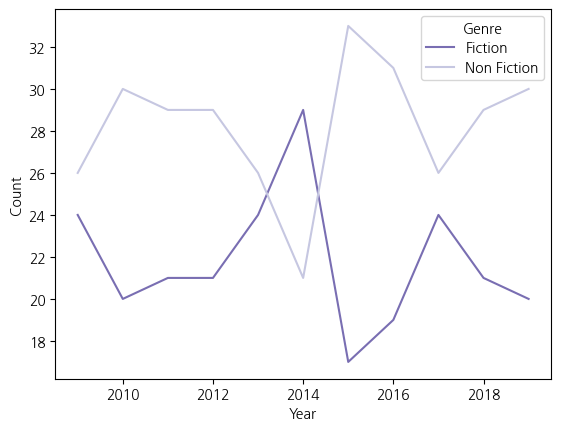

In [ ]:
books_df = pd.read_csv('amazon_bestsellers.csv')
books_df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [ ]:
# 연도별 장르별 베스트셀러 수
books_groupby = books_df.groupby(['Year', 'Genre'])['Name'].count().reset_index()
books_groupby.rename(columns={'Name':'Count'}, inplace=True)

In [ ]:
books_groupby.head(1)

,Year,Genre,Count
0,2009,Fiction,24


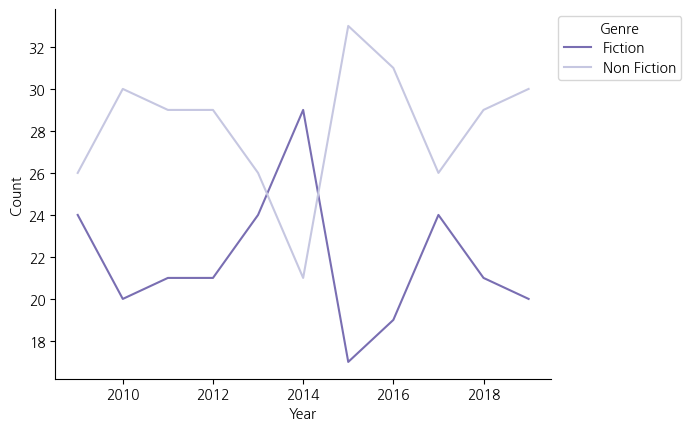

In [ ]:
# 시각화
ax = sns.lineplot(data=books_groupby, x='Year', y='Count', hue='Genre', palette='Purples_r')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
sns.despine()

(전체 그래프 설정 변경하기)

- sns.set_style() : 그래프의 스타일을 바꿔주는 함수로, seaborn에서 제공하는 기본 스타일은 dark, white, darkgrid, whitegrid, ticks
- sns.set_palette() : 전체 실행 환경의 팔레트를 일괄적으로 바꿔주는 함수
- sns.set_theme() : 배경, 스타일, 색상 등 전체적인 테마와 관련된 함수

<Axes: xlabel='Year', ylabel='Count'>

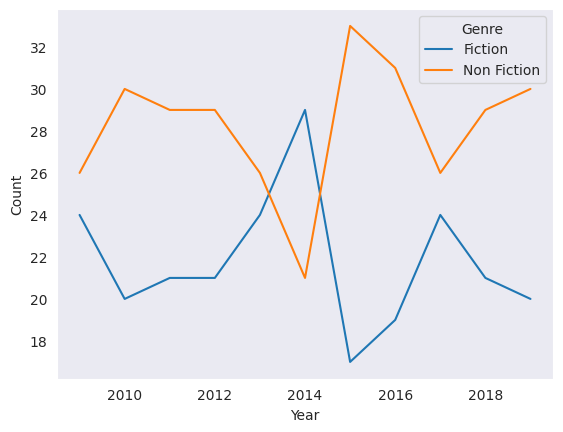

In [ ]:
sns.set_style('dark')
sns.lineplot(data=books_groupby, x='Year', y='Count', hue='Genre')

<Axes: xlabel='Year', ylabel='Count'>

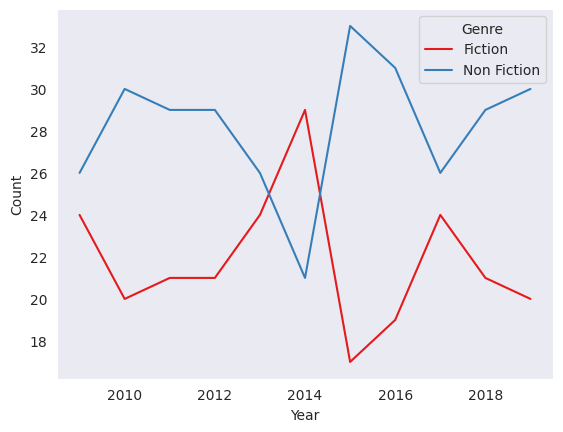

In [ ]:
sns.set_palette('Set1')
sns.lineplot(data=books_groupby, x='Year', y='Count', hue='Genre')

<Axes: xlabel='Year', ylabel='Count'>

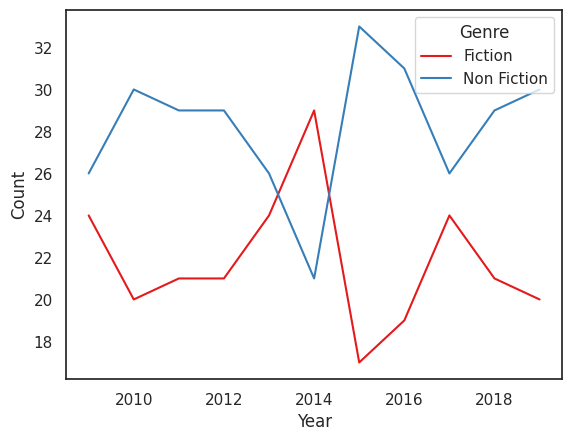

In [ ]:
sns.set_theme(style='white', palette='Set1')
sns.lineplot(data=books_groupby, x='Year', y='Count', hue='Genre')

### (2) matplotlib으로 커스터마이징

In [ ]:
books_df = pd.read_csv('amazon_bestsellers.csv')
books_df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [ ]:
# 연도별 장르별 베스트셀러 수
books_groupby = books_df.groupby(['Year', 'Genre'])['Name'].count().reset_index()
books_groupby.rename(columns={'Name':'Count'}, inplace=True)

In [ ]:
books_groupby.head(1)

,Year,Genre,Count
0,2009,Fiction,24


(Object-oriented 인터페이스)

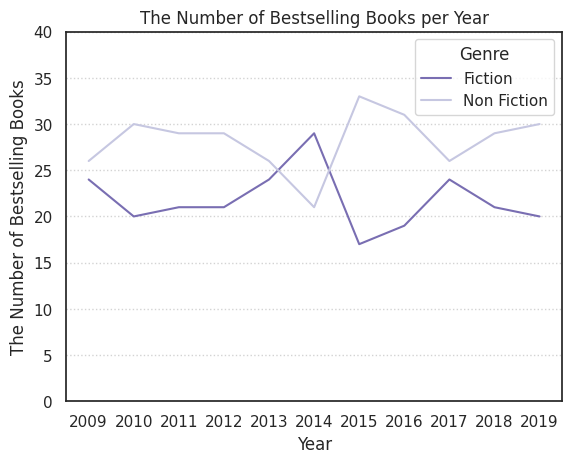

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(data=books_groupby, x='Year', y='Count', hue='Genre', palette='Purples_r', ax=ax)

ax.set_title('The Number of Bestselling Books per Year')
ax.set_ylabel('The Number of Bestselling Books')

ax.set_ylim([0, 40])
ax.set_xticks(books_groupby['Year'].unique())

ax.grid(axis='y', linestyle=':', color='lightgrey')

plt.show()

(Object-oriented 인터페이스 : 여러 개의 Axes 다루기)

In [ ]:
books_df.head(1)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction


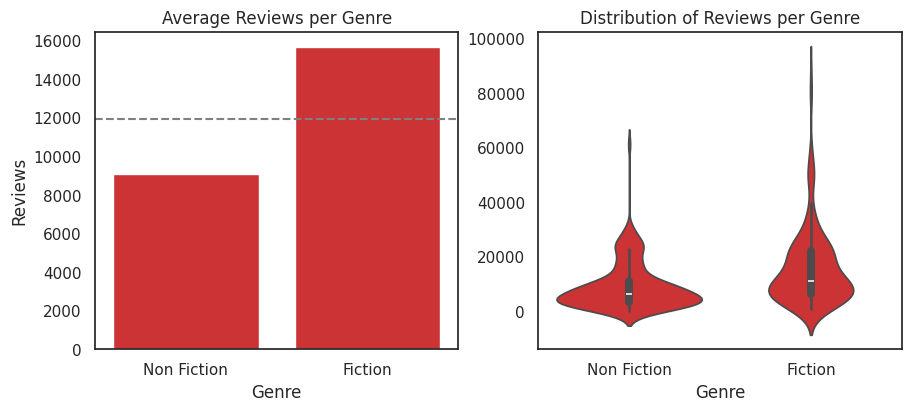

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

sns.barplot(data=books_df, x='Genre', y='Reviews', errorbar=None, ax=ax1)
sns.violinplot(data=books_df, x='Genre', y='Reviews', ax=ax2)

# ax1
ax1.set_title('Average Reviews per Genre')
ax1.axhline(books_df['Reviews'].mean(), color='grey', linestyle='--')

# ax2
ax2.set_title('Distribution of Reviews per Genre')
ax2.set_ylabel('')

plt.show()

# [3] plotly

[plotly](https://plotly.com/python/?utm_source=chatgpt.com)

**plotly**

- 최소한의 코드만으로도 상호작용이 가능한(interactive) 동적인 그래프를 그릴 수 있게 해주는 시각화 라이브러리로 plotly의 동적인 그래프를 활용하면 데이터를 다각적으로 살펴보는 데에 도움이 된다.

1. Plotly Graph Objects : low-level 인터페이스. 필요한 모든 작업 단계를 하나씩 짚어가며 자세히 설명해줘야 하는 인터페이스로 원하는 시각화를 구현하기 위해 일일이 코드를 작성해줘야 하는 불편함이 있지만 그 대신 자세하게 구성 요소들을 조정할 수 있는 높은 자유도가 보장되는 인터페이스이다.

2. Plotly Express : high-level 인터페이스. 간단한 코드로 대부분의 작업을 수행할 수 있게 해주고, Plotly Graph Objects를 기반으로 동작하며 보다 간단한 시각화가 가능한 인터페이스이다.

In [ ]:
birth_df = pd.read_csv('birth_rate.csv')
birth_df.head()

,지역,시점,연령대,여성 천명당 출생아수
0,서울특별시,2015,15-19세,1.0
1,서울특별시,2015,20-24세,6.4
2,서울특별시,2015,25-29세,38.1
3,서울특별시,2015,30-34세,100.4
4,서울특별시,2015,35-39세,49.6


(Plotly Graph Objects)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

for age, group in birth_df.groupby('연령대'):
    fig.add_trace(go.Scatter(x=group['시점'], y=group['여성 천명당 출생아수'], name=age, mode='lines',
                  hovertemplate='연령대=%s<br>시점=%%{x}<br>여성 천명당 출생아수=%%{y}<extra></extra>'% age))

fig.update_layout(legend_title_text='연령대')
fig.update_xaxes(title_text='시점')
fig.update_yaxes(title_text='여성 천명당 출생아수')
fig.show()

(Plotly Express)

In [ ]:
birth_df.head(1)

,지역,시점,연령대,여성 천명당 출생아수
0,서울특별시,2015,15-19세,1.0


In [ ]:
import plotly.express as px

px.line(birth_df, x='시점', y='여성 천명당 출생아수', color='연령대')

## 비교 및 추세 시각화

### (1) Bar Plot

In [ ]:
recruit_df = pd.read_csv('campus_recruitment.csv')
recruit_df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
# 대학 전공에 따른 평균 제안 급여 집계
recruit_groupby1 = recruit_df.groupby(['degree_t'])['salary'].mean().reset_index()
recruit_groupby1

,degree_t,salary
0,Comm&Mgmt,196000.000000
1,Others,127454.545455
2,Sci&Tech,218627.118644


In [ ]:
px.bar(recruit_groupby1, x='degree_t', y='salary')

In [ ]:
recruit_df.head(1)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.0,Others,91.0,Others,Commerce,58.0,Sci&Tech,No,55.0,Mkt&HR,58.8,Placed,270000.0


In [ ]:
# 대학 전공별 업무 경험별 평균 제안 급여 집계
recruit_groupby2 = recruit_df.groupby(['degree_t', 'workex'])['salary'].mean().reset_index()
recruit_groupby2

,degree_t,workex,salary
0,Comm&Mgmt,No,167590.000000
1,Comm&Mgmt,Yes,259133.333333
2,Others,No,70285.714286
3,Others,Yes,227500.000000
4,Sci&Tech,No,178264.705882
5,Sci&Tech,Yes,273520.000000


In [ ]:
px.bar(recruit_groupby2, x='degree_t', y='salary', color='workex', barmode='group') # barmode='group' : 막대를 위로 쌓는 대신 각 색상을 구분된 그룹으로 간주해 양옆으로 나란히 배치

In [ ]:
px.bar(recruit_groupby2, x='degree_t', y='salary', facet_col='workex', color='workex')

### (2) Line Plot

In [ ]:
gapminder_df = pd.read_csv('gapminder_1960to2020.csv')
gapminder_df.head()

,Country,Continent,Year,Population,Life Expectancy,GDP per Cap,Military Expenditure
0,Australia,Oceania,1960,10.30,71.1,1810.0,460.00
1,Austria,Europe,1960,7.05,69.0,935.0,91.60
2,Belgium,Europe,1960,9.11,70.1,1270.0,383.00
3,Benin,Africa,1960,2.51,44.8,93.0,1.30
4,Burkina Faso,Africa,1960,4.78,39.5,68.4,1.27


In [ ]:
px.line(gapminder_df.query("Country == 'South Korea'"),
        x='Year',
        y='Life Expectancy')

(동아시아 3국의 연도별 기대 수명 추이)

In [ ]:
temp = gapminder_df.query("Country in ['South Korea', 'Japan', 'China']")

In [ ]:
px.line(temp,
        x='Year',
        y='Life Expectancy',
        color='Country')

## 비중 및 구성 시각화

### (1) Pie Plot

In [ ]:
gapminder_df = pd.read_csv('gapminder_1960to2020.csv')
gapminder_df.head()

,Country,Continent,Year,Population,Life Expectancy,GDP per Cap,Military Expenditure
0,Australia,Oceania,1960,10.30,71.1,1810.0,460.00
1,Austria,Europe,1960,7.05,69.0,935.0,91.60
2,Belgium,Europe,1960,9.11,70.1,1270.0,383.00
3,Benin,Africa,1960,2.51,44.8,93.0,1.30
4,Burkina Faso,Africa,1960,4.78,39.5,68.4,1.27


In [ ]:
# 2020년 아시아 국가
gapminder_asia = gapminder_df.query("Year == 2020 & Continent == 'Asia'").copy()

In [ ]:
gapminder_asia.sort_values(by='Population', ascending=False, inplace=True)

In [ ]:
# 인구 기준 상위 10개 국가만 남겨두고 나머지 국가들은 기타 국가로 분류
gapminder_asia.iloc[10:, 0] = 'Other Countries'

In [ ]:
gapminder_asia.head(1)

,Country,Continent,Year,Population,Life Expectancy,GDP per Cap,Military Expenditure
6895,China,Asia,2020,1420.0,77.7,10400.0,252000.0


In [ ]:
# 2020년 아시아 국가 인구 비율
px.pie(gapminder_asia, values='Population', names='Country')

### (2) Treemap

- 한 그룹 안에 다른 그룹이 포함되는 계층 구조를 가진 데이터의 크기를 시각화하기에 적합한 그래프

In [ ]:
# 2020년 기준 국가별 인구 정보
px.treemap(gapminder_df.query("Year == 2020"),
           path=['Continent', 'Country'],
           values='Population')

### (3) Sunburst Chart

In [ ]:
# 2020년 기준 국가별 인구 정보
px.sunburst(gapminder_df.query("Year == 2020"),
           path=['Continent', 'Country'],
           values='Population')

In [ ]:
# 2020년 기준 국가별 인구 정보(Life Expectancy 추가)
px.sunburst(gapminder_df.query("Year == 2020"),
           path=['Continent', 'Country'],
           values='Population',
           color='Life Expectancy')

## 분포 시각화

### (1) Strip Plot

`px.strip()`

In [ ]:
recruit_df = pd.read_csv('campus_recruitment.csv')
recruit_df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
px.strip(recruit_df,
         x='degree_t',
         y='salary',
         color='workex')

### (2) Box Plot

`px.box()`

In [ ]:
px.box(recruit_df,
       x='degree_t',
       y='salary',
       color='workex',
       points='all')

### (3) Violin Plot

`px.violin()`

In [ ]:
px.violin(recruit_df,
          x='degree_t',
          y='salary',
          color='workex',
          box=True,
          points='all')

### (4) Histogram

`px.histogram()`

In [ ]:
px.histogram(recruit_df,
             x='salary',
             color='workex',
             facet_col='workex')

## 산점 및 관계 시각화

### (1) Scatter Plot

In [ ]:
pokemon_df = pd.read_csv('pokemon.csv')
pokemon_df.head()

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,3,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [ ]:
px.scatter(pokemon_df,
           x='attack',
           y='defense',
           hover_name='name',
           color='legendary',
           symbol='legendary')

In [ ]:
px.scatter(pokemon_df,
           x='attack',
           y='defense',
           color='total',
           hover_name='name')

### (2) Bubble Chart

`px.scatter()`

In [ ]:
gapminder_df = pd.read_csv('gapminder_1960to2020.csv')
gapminder_df.head()

,Country,Continent,Year,Population,Life Expectancy,GDP per Cap,Military Expenditure
0,Australia,Oceania,1960,10.30,71.1,1810.0,460.00
1,Austria,Europe,1960,7.05,69.0,935.0,91.60
2,Belgium,Europe,1960,9.11,70.1,1270.0,383.00
3,Benin,Africa,1960,2.51,44.8,93.0,1.30
4,Burkina Faso,Africa,1960,4.78,39.5,68.4,1.27


In [ ]:
# 2020년
px.scatter(gapminder_df.query("Year == 2020"),
           x='GDP per Cap',
           y='Life Expectancy',
           size='Population',  # size 추가
           hover_name='Country',
           color='Continent',
           size_max=40)

### (3) Dot Plot

`px.scatter()`

- Scatter Plot의 변형 형태 중 하나로, Scatter Plot은 흔히 x와 y 모두 연속형 변수인데, 한쪽에 카테고리 변수를 넣어준 형태가 Dot Plot

In [ ]:
# 북미, 2000년 이후 데이터로만 한정
temp = gapminder_df.query("Continent=='North America' & Year >= 2000")
px.scatter(temp,
           x='Life Expectancy',
           y='Country',
           color='Year')

## 퍼널 차트

### (1) Funnel Chart

**퍼널 분석(Funnel Analysis)**

- 유저 행동의 연속적인 단계를 수치로 확인하는 분석 방법으로 단계별 유저 수가 점점 적어지기 때문에 깔때기 모양처럼 보여서 퍼널이라고 부른다. 예를 들어, 이커머스 웹사이트라면 '사이트 방문(visit_area) -> 상품 상세 페이지 확인(click_product) -> 장바구니에 담기(add_to_cart) -> 구매(purchase)'와 같은 퍼널을 가질 수 있고, 점점 퍼널의 아래 단계로 들어갈수록 남아 있는 유저 수가 적어진다.

In [ ]:
funnel_df = pd.read_csv('/content/ecommerce_funnel.csv')
funnel_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/ecommerce_funnel.csv'

- `px.funnel()`에서 x에는 숫자형 컬럼이 들어가고, y에는 퍼널의 단계를 담은 컬럼이 들어간다.

In [ ]:
px.funnel(funnel_df.query("event_area=='search_result'"),
          x='user_count',
          y='funnel')

In [ ]:
px.funnel(funnel_df,
          x='user_count',
          y='funnel',
          color='event_area',
          facet_col='event_area')

## Plotly Express 활용

### (1) 구성요소 다루기

1. 제목 붙이기
2. 변수명 변경하기
3. 값의 순서 조정하기
4. 색상 팔레트 변경
5. 막대 위에 값 표기하기
6. 수치 표현하기
7. 그래프 크기 지정하기

In [ ]:
# 데이터 불러오기
recruit_df = pd.read_csv('campus_recruitment.csv')
recruit_df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
# 대학 전공별 업무 경험별 평균 제안 급여
recruit_groupby = recruit_df.groupby(['degree_t', 'workex'])['salary'].mean().reset_index()
recruit_groupby

,degree_t,workex,salary
0,Comm&Mgmt,No,167590.000000
1,Comm&Mgmt,Yes,259133.333333
2,Others,No,70285.714286
3,Others,Yes,227500.000000
4,Sci&Tech,No,178264.705882
5,Sci&Tech,Yes,273520.000000


In [ ]:
# 템블릿 지정
import plotly.io as pio

pio.templates.default = 'plotly_white'

(제목 붙이기)

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',
       barmode='group',
       title='Average Offered Salary per Undergraduate Major')

(변수명 변경하기) labels={'원래 이름':'변경할 이름'}

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',
       barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'})

(값의 순서 조정하기)

In [ ]:
# 전공 : Sci&Tech, Comm&Mgmt, Others
# 업무 경험 : Yes, No

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',
       barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'},
       category_orders={'degree_t':['Sci&Tech', 'Comm&Mgmt', 'Others'], 'workex':['Yes', 'No']})

(색상 팔레트 변경 : 카테고리형 변수)
* color_discrete_sequence : color에 카테고리형 변수가 들어갈 때
* color_continuous_scale : color에 연속형 변수가 들어갈 때

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',  # 카테고리형 변수
       barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'},
       category_orders={'degree_t':['Sci&Tech', 'Comm&Mgmt', 'Others'], 'workex':['Yes', 'No']},
       color_discrete_sequence=px.colors.qualitative.Pastel)  # color_discrete_sequence : color에 카테고리형 변수가 들어갈 때

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       facet_col='workex',  # facet_col 추가
       color='salary',  # 연속형 변수
       #barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'},
       category_orders={'degree_t':['Sci&Tech', 'Comm&Mgmt', 'Others'], 'workex':['Yes', 'No']},
       color_continuous_scale='teal',
       facet_col_spacing=0.1)

(막대 위에 값 표기하기)

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',
       barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'},
       category_orders={'degree_t':['Sci&Tech', 'Comm&Mgmt', 'Others'], 'workex':['Yes', 'No']},
       color_discrete_sequence=px.colors.qualitative.Pastel,
       text_auto=True)

(수치 표현하기)

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',
       barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'},
       category_orders={'degree_t':['Sci&Tech', 'Comm&Mgmt', 'Others'], 'workex':['Yes', 'No']},
       color_discrete_sequence=px.colors.qualitative.Pastel,
       text_auto=',d')

(그래프 크기 지정하기)

In [ ]:
px.bar(recruit_groupby,
       x='degree_t',
       y='salary',
       color='workex',
       barmode='group',
       title='Average Offered Salary per Undergraduate Major',
       labels={'salary':'Average Salary', 'degree_t':'Undergraduate Major', 'workex':'Work Experience'},
       category_orders={'degree_t':['Sci&Tech', 'Comm&Mgmt', 'Others'], 'workex':['Yes', 'No']},
       color_discrete_sequence=px.colors.qualitative.Pastel,
       text_auto=',d',
       height=400, width=800)

### (2) hover 요소 다루기

1. hover name 지정하기
2. hover data 지정하기
3. hovermode 설정하기

In [ ]:
gapminder_df = pd.read_csv('gapminder_1960to2020.csv')
gapminder_df.head()

,Country,Continent,Year,Population,Life Expectancy,GDP per Cap,Military Expenditure
0,Australia,Oceania,1960,10.30,71.1,1810.0,460.00
1,Austria,Europe,1960,7.05,69.0,935.0,91.60
2,Belgium,Europe,1960,9.11,70.1,1270.0,383.00
3,Benin,Africa,1960,2.51,44.8,93.0,1.30
4,Burkina Faso,Africa,1960,4.78,39.5,68.4,1.27


In [ ]:
# 동아시아 3국 & 2000년 이후만 데이터 필터링
temp = gapminder_df.query("Country in ['South Korea', 'Japan', 'China'] & Year >= 2000")

In [ ]:
px.line(temp,
        x='Year',
        y='Life Expectancy',
        color='Country',
        markers=True)

(hover name 지정하기)

- hover_name은 각 데이터 포인트의 이름을 의미하는데, 각 데이터 포인트를 가장 잘 설명해주는 변수를 지정할 수 있다.

In [ ]:
px.line(temp,
        x='Year',
        y='Life Expectancy',
        color='Country',
        markers=True,
        hover_name='Country')

(hover data 지정하기)

- hover_data는 마우스를 올렸을 때 나타나는 박스에 보여줄 데이터를 포함

In [ ]:
px.line(temp,
        x='Year',
        y='Life Expectancy',
        color='Country',
        markers=True,
        hover_name='Country',
        hover_data=['Population', 'GDP per Cap'])

(hovermode 설정하기)

- 마우스를 올렸을 때, 어떤 형식으로 데이터를 보여줄지 지정할 수 있다.

In [ ]:
fig = px.line(temp,
        x='Year',
        y='Life Expectancy',
        color='Country',
        markers=True)

fig.update_traces(hovertemplate=None)  # 기본적인 박스 대신 값을 간소하게 보여줌
#fig.update_layout(hovermode='x')
fig.update_layout(hovermode='x unified')  # x축의 값을 모두 하나의 박스로 합쳐져서 보여줌

### (3) 그래프 공유하기

(HTML 파일로 저장)

In [ ]:
fig = px.scatter(range(10), range(10))
fig.write_html('/content/file.html')